# Campaign 25 manual split audit

This notebook renders the exact supervised multitile targets used by Campaign 25 for all 11 training fragments. Each fragment has its own visualization cell.

Color interpretation:

- **red**: training ink
- **yellow**: training papyrus ring negative
- **blue**: validation ink
- **green**: validation papyrus ring negative
- **cyan**: explicit manual negative
- **gray**: the real continuous ink label at 25% opacity

The helper uses the production `DataManager`, `_fetch_label_mt()`, and `_fetch_mask_mt()` paths. Each displayed pixel represents one 16 px model target. Fragments without a continuous `inklabels/<id>.png` fall back to the eroded label for the gray reference layer.

In [9]:
from pathlib import Path
import gc

import cv2
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

from campaign_archs_25 import TESTS, _SCROLL_IDS, build_config
from utils.dataloader import DataManager

ROOT = Path.cwd()
if ROOT.name == "old":
    ROOT = ROOT.parent

SAVE_PNG = True
OUT_DIR = ROOT / "output" / "campaign25_split_audit"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SCROLL_NAMES = {
    20260115000000: "PHerc0139 w044",
    20260317000000: "PHerc0139 w035",
    20250223000000: "PHerc0139 w059",
    20251111010954: "PHerc0172 w068",
    20251112000002: "PHerc0172 w087",
    20240304141531: "PHerc1667 w013",
    20240304144031: "PHerc1667 w018",
    20250919125754: "PHerc0009B 487",
    20231210121321: "PHercParis4",
    20250628074500: "PHerc0500P2",
    20260226000000: "PHerc0814",
}

assert tuple(SCROLL_NAMES) == _SCROLL_IDS

COLORS = {
    "train_ink": np.array([255, 0, 0], dtype=np.uint8),
    "train_papyrus": np.array([255, 220, 0], dtype=np.uint8),
    "valid_ink": np.array([0, 90, 255], dtype=np.uint8),
    "valid_papyrus": np.array([0, 190, 70], dtype=np.uint8),
    "explicit_negative": np.array([0, 255, 255], dtype=np.uint8),
}


def _read_gray(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(path)
    return image


def _real_inklabel(scroll_id):
    candidates = (
        (ROOT / "inklabels" / f"{scroll_id}.png", "continuous inklabel"),
        (ROOT / "inklabels" / "2_4um" / f"{scroll_id}.png", "archived 2.4 µm inklabel"),
        (ROOT / "inklabels" / "1_1um" / f"{scroll_id}.png", "archived 1.1 µm inklabel"),
        (ROOT / "eroded_inklabels" / f"{scroll_id}.png", "eroded fallback"),
    )
    for path, description in candidates:
        if path.exists():
            return _read_gray(path), description
    raise FileNotFoundError(f"no ink reference found for {scroll_id}")


def _campaign25_audit_config():
    cfg = build_config(TESTS[0])
    cfg.data.preload_volumes = False
    cfg.data.mask_memmap = False
    cfg.data.mask_bitpack = False
    cfg.data.character_balanced_sampling = False
    cfg.tra.character_macro_metrics = False
    cfg.dl.data_aug = False
    return cfg


def _collect_targets(dataset, maps):
    n = dataset._mt_grid
    sub = dataset._mt_sub
    for _, y_off, x_off in dataset.block_coords:
        labels = dataset._fetch_label_mt(y_off, x_off).numpy()
        valid = dataset._fetch_mask_mt(y_off, x_off).numpy() > 0
        y0, _, x0, _ = dataset._mt_center_bounds(y_off, x_off)
        for index in np.flatnonzero(valid):
            iy, ix = divmod(int(index), n)
            ys = y0 + iy * sub
            xs = x0 + ix * sub
            cy = (ys + sub // 2) // sub
            cx = (xs + sub // 2) // sub
            if not (0 <= cy < maps["shape"][0] and 0 <= cx < maps["shape"][1]):
                continue
            value = labels[index]
            if value < 0:
                maps["explicit_negative"][cy, cx] = True
            elif value > 0:
                maps[f"{maps['split']}_ink"][cy, cx] = True
            else:
                maps[f"{maps['split']}_papyrus"][cy, cx] = True


def render_scroll(scroll_id, name):
    cfg = _campaign25_audit_config()
    scroll_index = list(_SCROLL_IDS).index(int(scroll_id))
    dm = DataManager(
        cfg,
        scroll_id=int(scroll_id),
        domain_id=scroll_index,
        character_namespace=scroll_index,
    )
    train_set, valid_set = dm.get_datasets()

    height, width = dm.labels.shape
    sub = int(cfg.model.multitile_subtile)
    display_shape = (int(np.ceil(height / sub)) + 1, int(np.ceil(width / sub)) + 1)
    target_maps = {key: np.zeros(display_shape, dtype=bool) for key in COLORS}
    target_maps["shape"] = display_shape

    target_maps["split"] = "train"
    _collect_targets(train_set, target_maps)
    target_maps["split"] = "valid"
    _collect_targets(valid_set, target_maps)
    target_maps.pop("split")
    target_maps.pop("shape")

    train_any = target_maps["train_ink"] | target_maps["train_papyrus"] | target_maps["explicit_negative"]
    valid_any = target_maps["valid_ink"] | target_maps["valid_papyrus"]
    assert not np.any(train_any & valid_any), f"train/validation overlap for {scroll_id}"

    raw, raw_source = _real_inklabel(scroll_id)
    background = cv2.resize(
        raw,
        (display_shape[1], display_shape[0]),
        interpolation=cv2.INTER_AREA,
    )
    rgb = np.repeat(background[..., None], 3, axis=2).astype(np.float32) * 0.25
    rgb = rgb.astype(np.uint8)

    for key in ("train_ink", "train_papyrus", "valid_ink", "valid_papyrus"):
        rgb[target_maps[key]] = COLORS[key]
    rgb[target_maps["explicit_negative"]] = COLORS["explicit_negative"]

    counts = {key: int(target_maps[key].sum()) for key in COLORS}
    supervised = sum(counts.values())
    fig, ax = plt.subplots(figsize=(18, max(6, 18 * height / width)))
    ax.imshow(rgb, interpolation="nearest")
    ax.set_title(
        f"{name} — {scroll_id}\n"
        f"real ink reference={raw_source} at 25% opacity; "
        f"supervised targets={supervised:,}; target={sub}px"
    )
    ax.axis("off")
    legend = [
        mpatches.Patch(color=COLORS["train_ink"] / 255, label=f"train ink ({counts['train_ink']:,})"),
        mpatches.Patch(color=COLORS["train_papyrus"] / 255, label=f"train papyrus ({counts['train_papyrus']:,})"),
        mpatches.Patch(color=COLORS["valid_ink"] / 255, label=f"validation ink ({counts['valid_ink']:,})"),
        mpatches.Patch(color=COLORS["valid_papyrus"] / 255, label=f"validation papyrus ({counts['valid_papyrus']:,})"),
        mpatches.Patch(color=COLORS["explicit_negative"] / 255, label=f"explicit negative ({counts['explicit_negative']:,})"),
        mpatches.Patch(color=(0.25, 0.25, 0.25), label=f"real ink label ({raw_source}, 25%)"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=9, framealpha=0.95)
    plt.tight_layout()

    out_path = OUT_DIR / f"{scroll_id}_campaign25_split.png"
    if SAVE_PNG:
        fig.savefig(out_path, dpi=180, bbox_inches="tight")
        print(f"saved {out_path}")
    print(counts)
    plt.show()

    del train_set, valid_set, dm, raw, background, rgb, target_maps
    gc.collect()


print("Campaign 25 audit helper ready for 11 fragments")

Campaign 25 audit helper ready for 11 fragments


[align] scroll 20260115000000: volume=(6040, 8160) mask=(6040, 8160) labels=(6021, 8141) -> common=(6021, 8141)
[split] scroll 20260115000000: manual mask=./train_masks/20260115000000.png train_pixels=3.5% explicit_negative_pixels=688,128
[split] scroll 20260115000000: axis=y train_frac=0.8055
[ring] closed(base=eroded): CLOSE_R=3 GAP_R=3 exclusion_tiles=4093
[ring_negatives] source='closed' tile_radius=2  ink_tiles=1243  ring_tiles=1566  ratio=1.26
[manual-split] scroll 20260115000000: unit=16px train_ring=561152px valid_ring=157952px
[context-replace] scroll 20260115000000: 2161 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign25_split_audit/20260115000000_campaign25_split.png
{'train_ink': 613, 'train_papyrus': 320, 'valid_ink': 177, 'valid_papyrus': 134, 'explicit_negative': 2084}


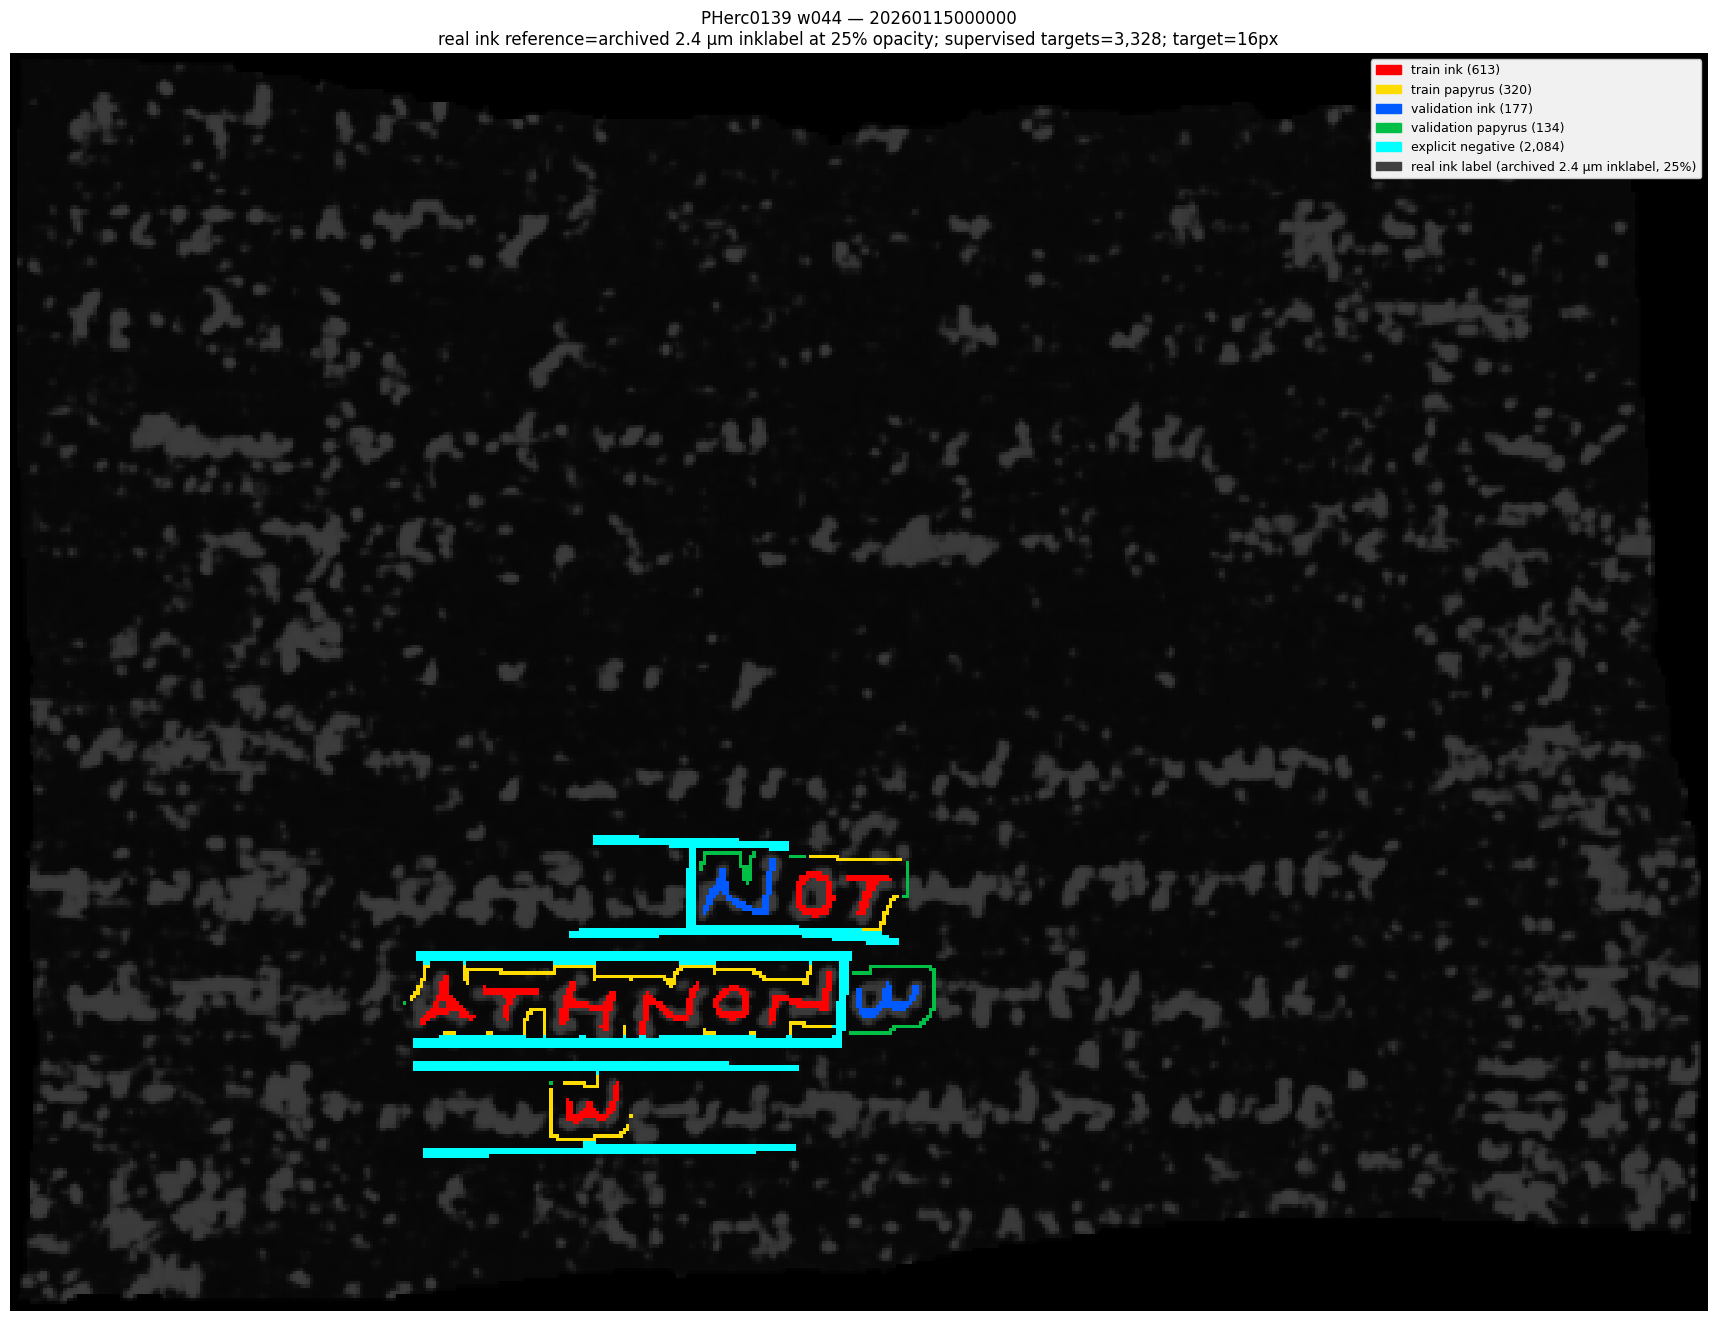

In [11]:
render_scroll(20260115000000, SCROLL_NAMES[20260115000000])

[split] scroll 20260317000000: manual mask=./train_masks/20260317000000.png train_pixels=7.0% explicit_negative_pixels=676,352
[split] scroll 20260317000000: axis=y train_frac=0.75
[ring] closed(base=eroded): CLOSE_R=3 GAP_R=3 exclusion_tiles=5272
[ring_negatives] source='closed' tile_radius=2  ink_tiles=1657  ring_tiles=2401  ratio=1.45
[manual-split] scroll 20260317000000: unit=16px train_ring=752384px valid_ring=286464px
[context-replace] scroll 20260317000000: 2698 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign25_split_audit/20260317000000_campaign25_split.png
{'train_ink': 748, 'train_papyrus': 507, 'valid_ink': 292, 'valid_papyrus': 282, 'explicit_negative': 2042}


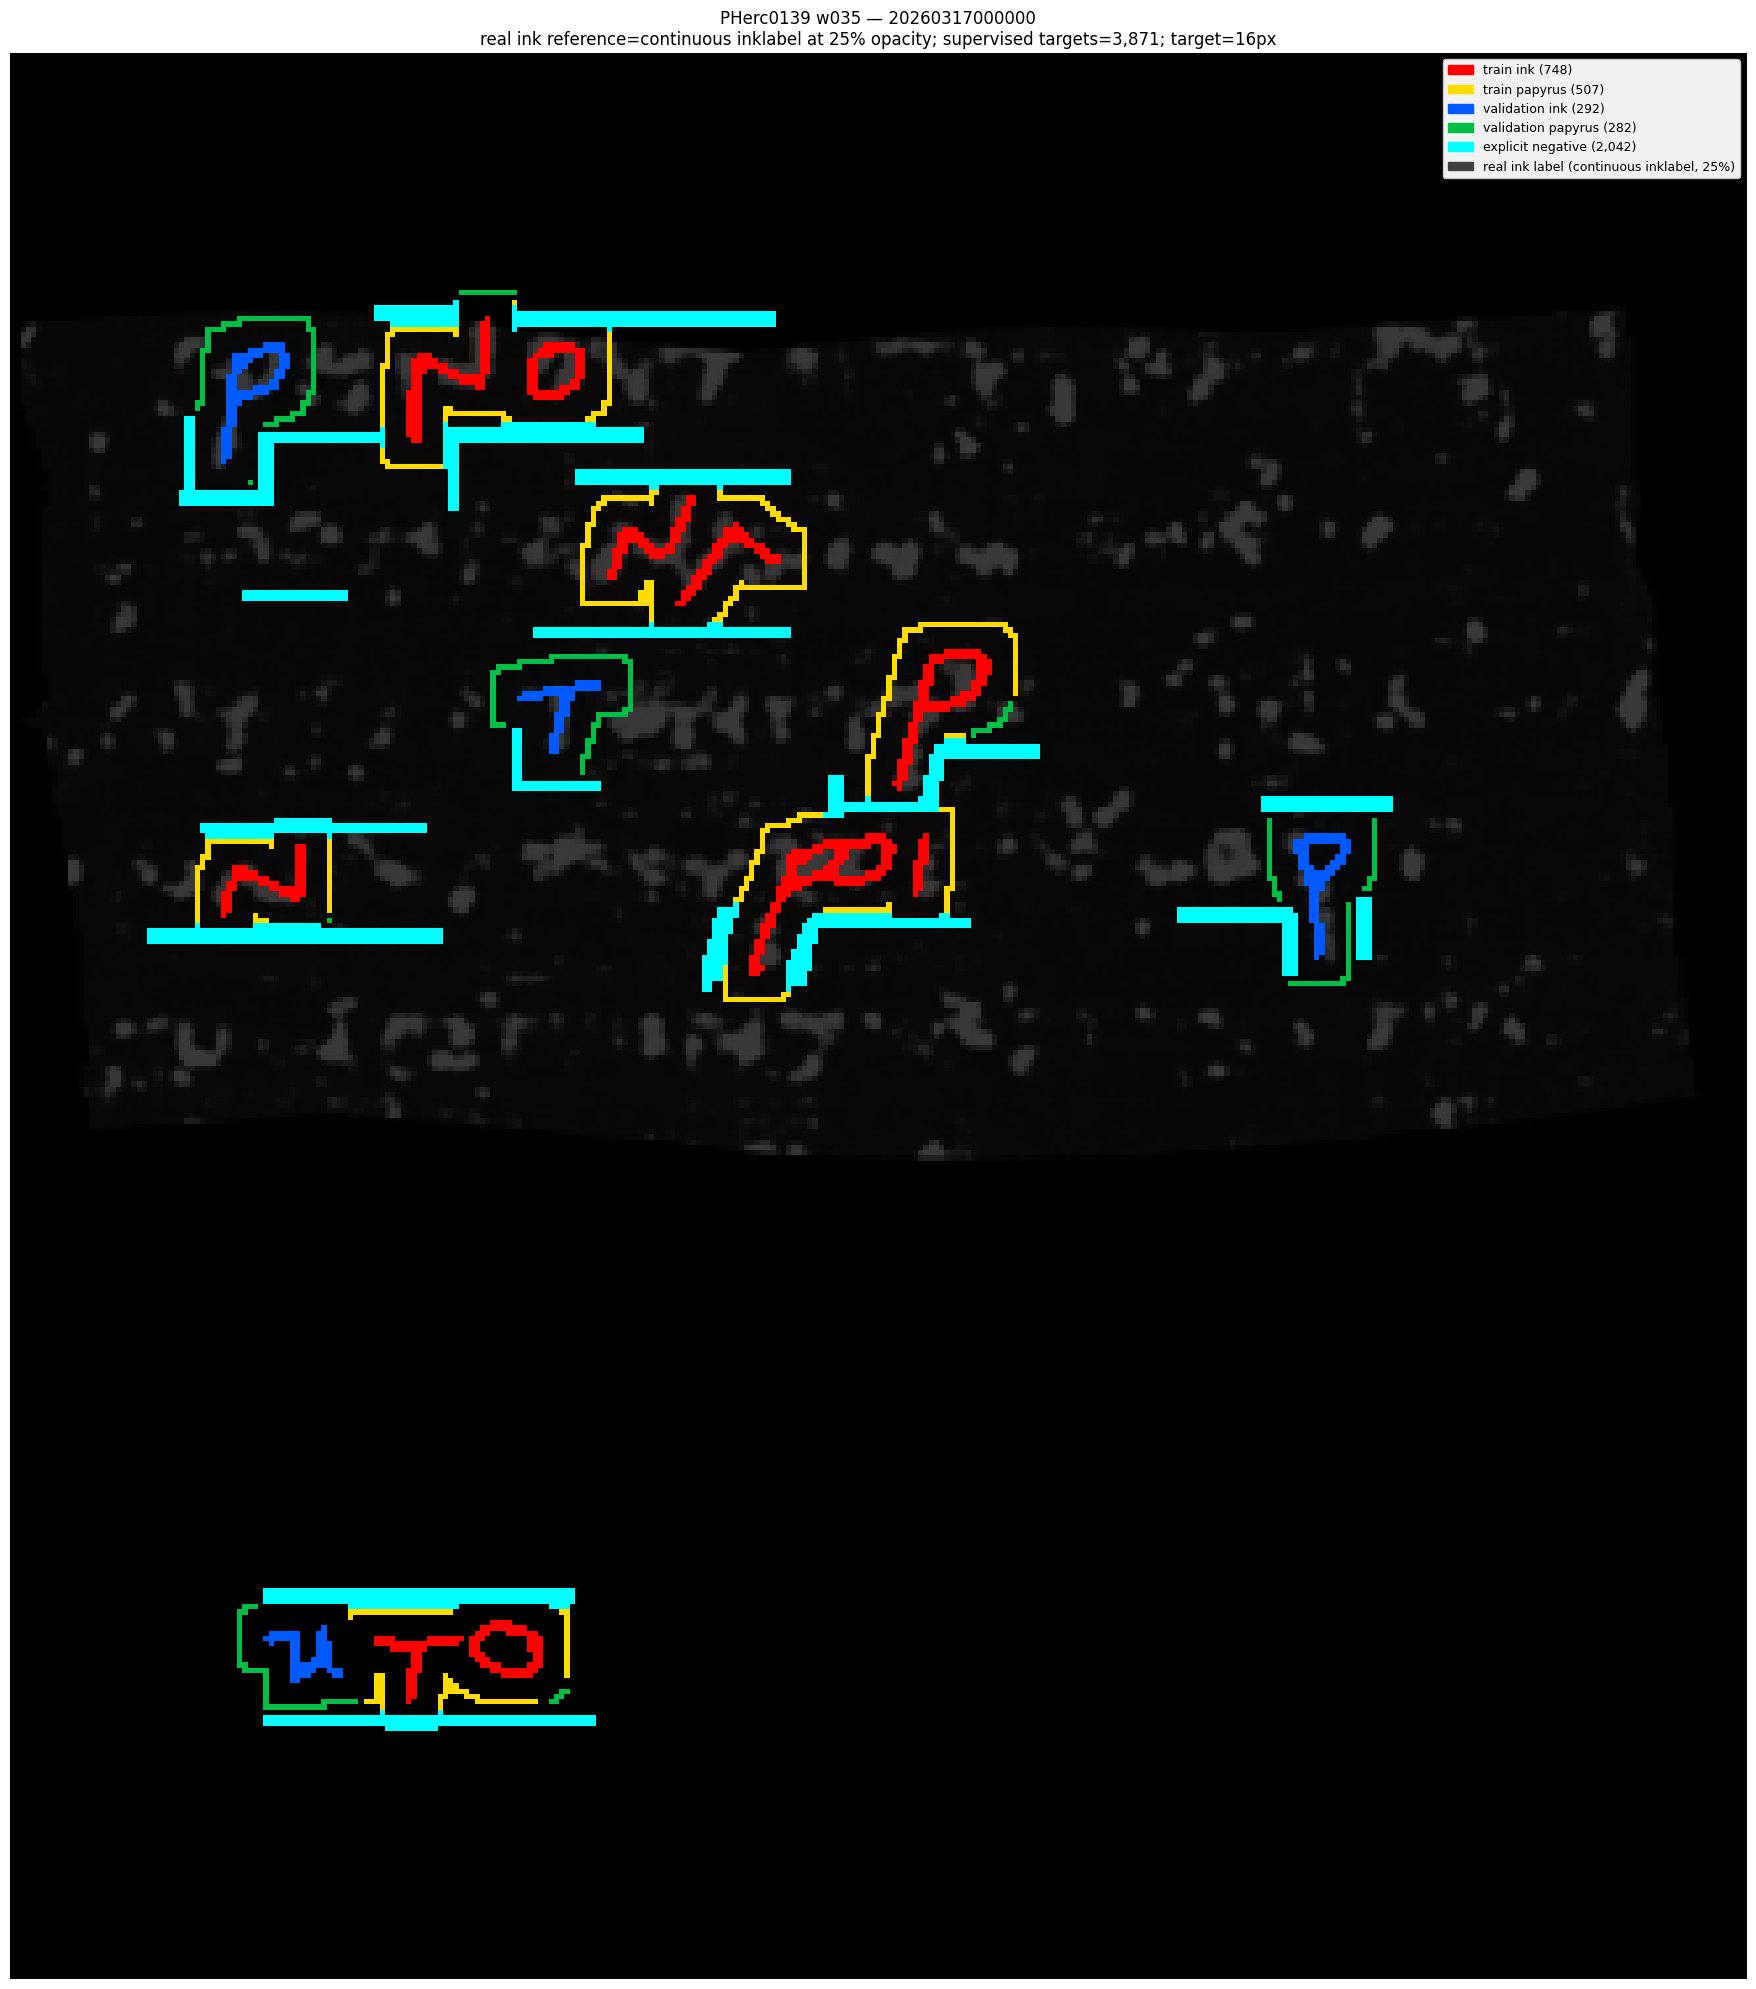

In [7]:
render_scroll(20260317000000, SCROLL_NAMES[20260317000000])

[explicit-negative] scroll 20250223000000: overriding 1 ink-label pixels
[split] scroll 20250223000000: manual mask=./train_masks/20250223000000.png train_pixels=2.4% explicit_negative_pixels=651,520
[split] scroll 20250223000000: axis=x train_frac=0.75
[ring] closed(base=eroded): CLOSE_R=3 GAP_R=3 exclusion_tiles=3877
[ring_negatives] source='closed' tile_radius=2  ink_tiles=1198  ring_tiles=1803  ratio=1.51
[manual-split] scroll 20250223000000: unit=16px train_ring=485376px valid_ring=282880px
[context-replace] scroll 20250223000000: 2925 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign25_split_audit/20250223000000_campaign25_split.png
{'train_ink': 414, 'train_papyrus': 447, 'valid_ink': 353, 'valid_papyrus': 260, 'explicit_negative': 1912}


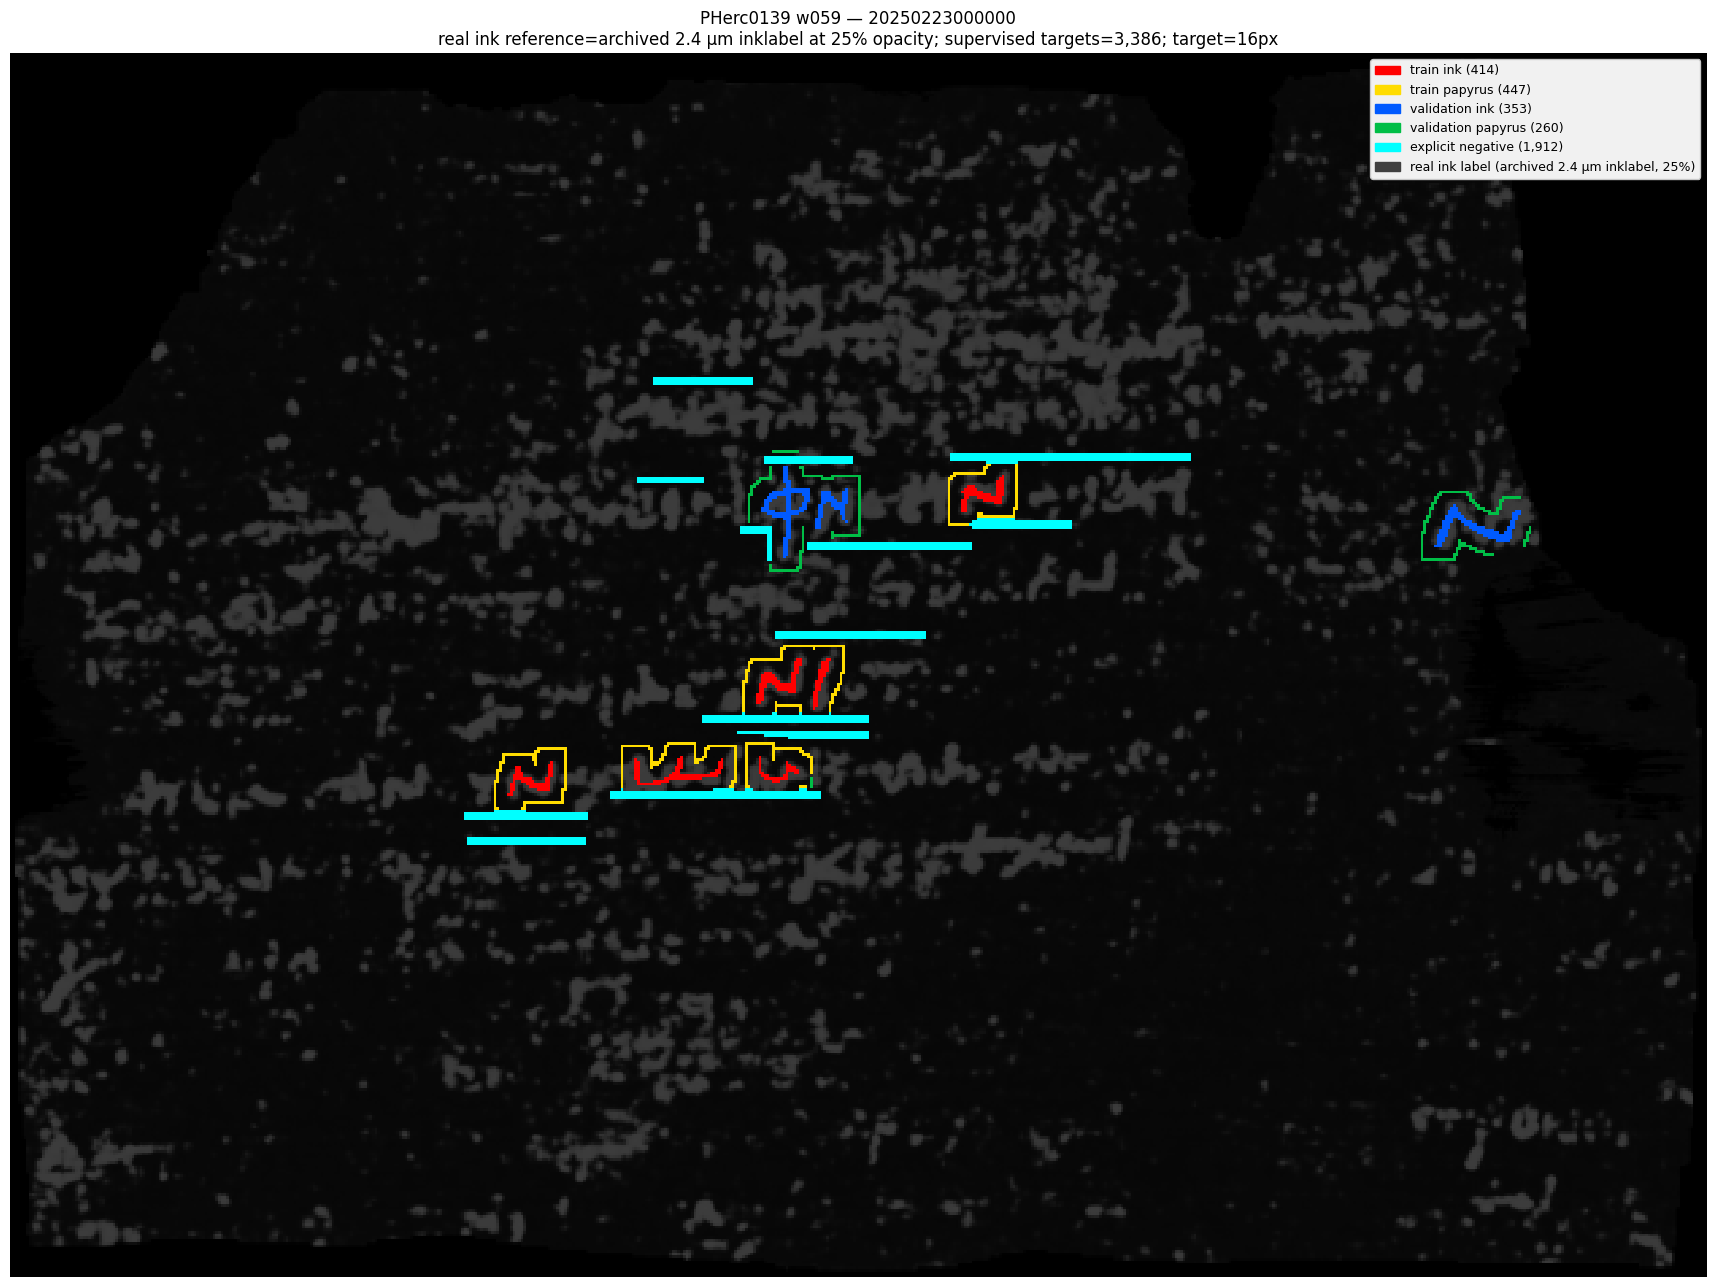

In [12]:
render_scroll(20250223000000, SCROLL_NAMES[20250223000000])

[split] scroll 20251111010954: manual mask=./train_masks/20251111010954.png train_pixels=2.6% explicit_negative_pixels=998,144
[split] scroll 20251111010954: axis=x train_frac=0.75
[ring] closed(base=eroded): CLOSE_R=3 GAP_R=3 exclusion_tiles=4966
[ring_negatives] source='closed' tile_radius=2  ink_tiles=1354  ring_tiles=2489  ratio=1.84
[manual-split] scroll 20251111010954: unit=16px train_ring=756992px valid_ring=226816px
[context-replace] scroll 20251111010954: 8047 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign25_split_audit/20251111010954_campaign25_split.png
{'train_ink': 592, 'train_papyrus': 823, 'valid_ink': 185, 'valid_papyrus': 286, 'explicit_negative': 2987}


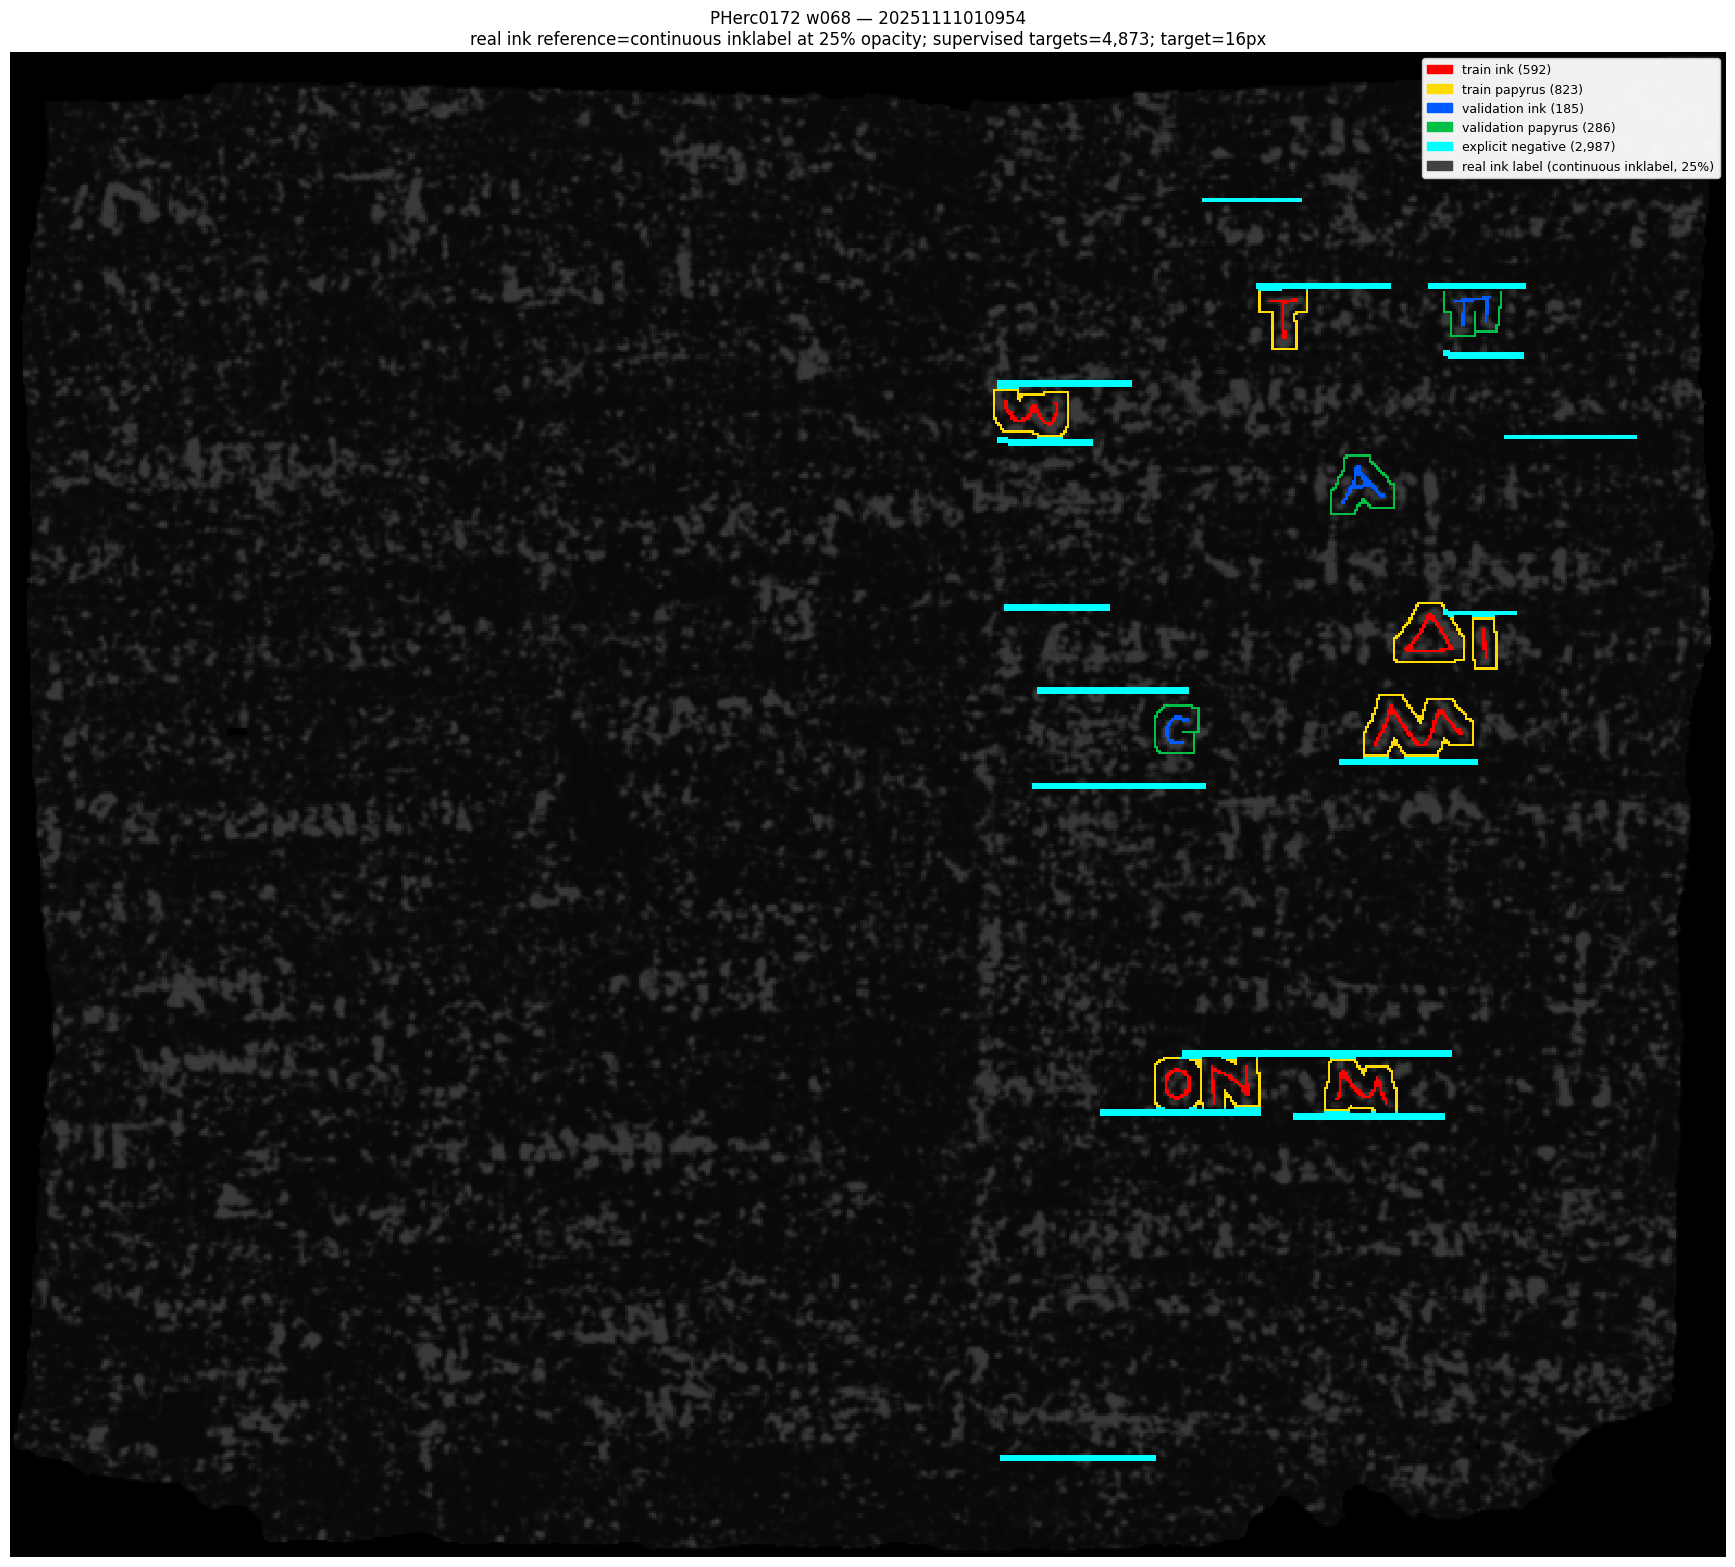

In [13]:
render_scroll(20251111010954, SCROLL_NAMES[20251111010954])

[split] scroll 20251112000002: manual mask=./train_masks/20251112000002.png train_pixels=9.7% explicit_negative_pixels=1,844,736
[split] scroll 20251112000002: axis=x train_frac=0.75
[ring] closed(base=eroded): CLOSE_R=3 GAP_R=3 exclusion_tiles=13844
[ring_negatives] source='closed' tile_radius=2  ink_tiles=3812  ring_tiles=6712  ratio=1.76
[manual-split] scroll 20251112000002: unit=16px train_ring=1933056px valid_ring=761088px
[context-replace] scroll 20251112000002: 17339 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign25_split_audit/20251112000002_campaign25_split.png
{'train_ink': 1649, 'train_papyrus': 2223, 'valid_ink': 567, 'valid_papyrus': 994, 'explicit_negative': 5288}


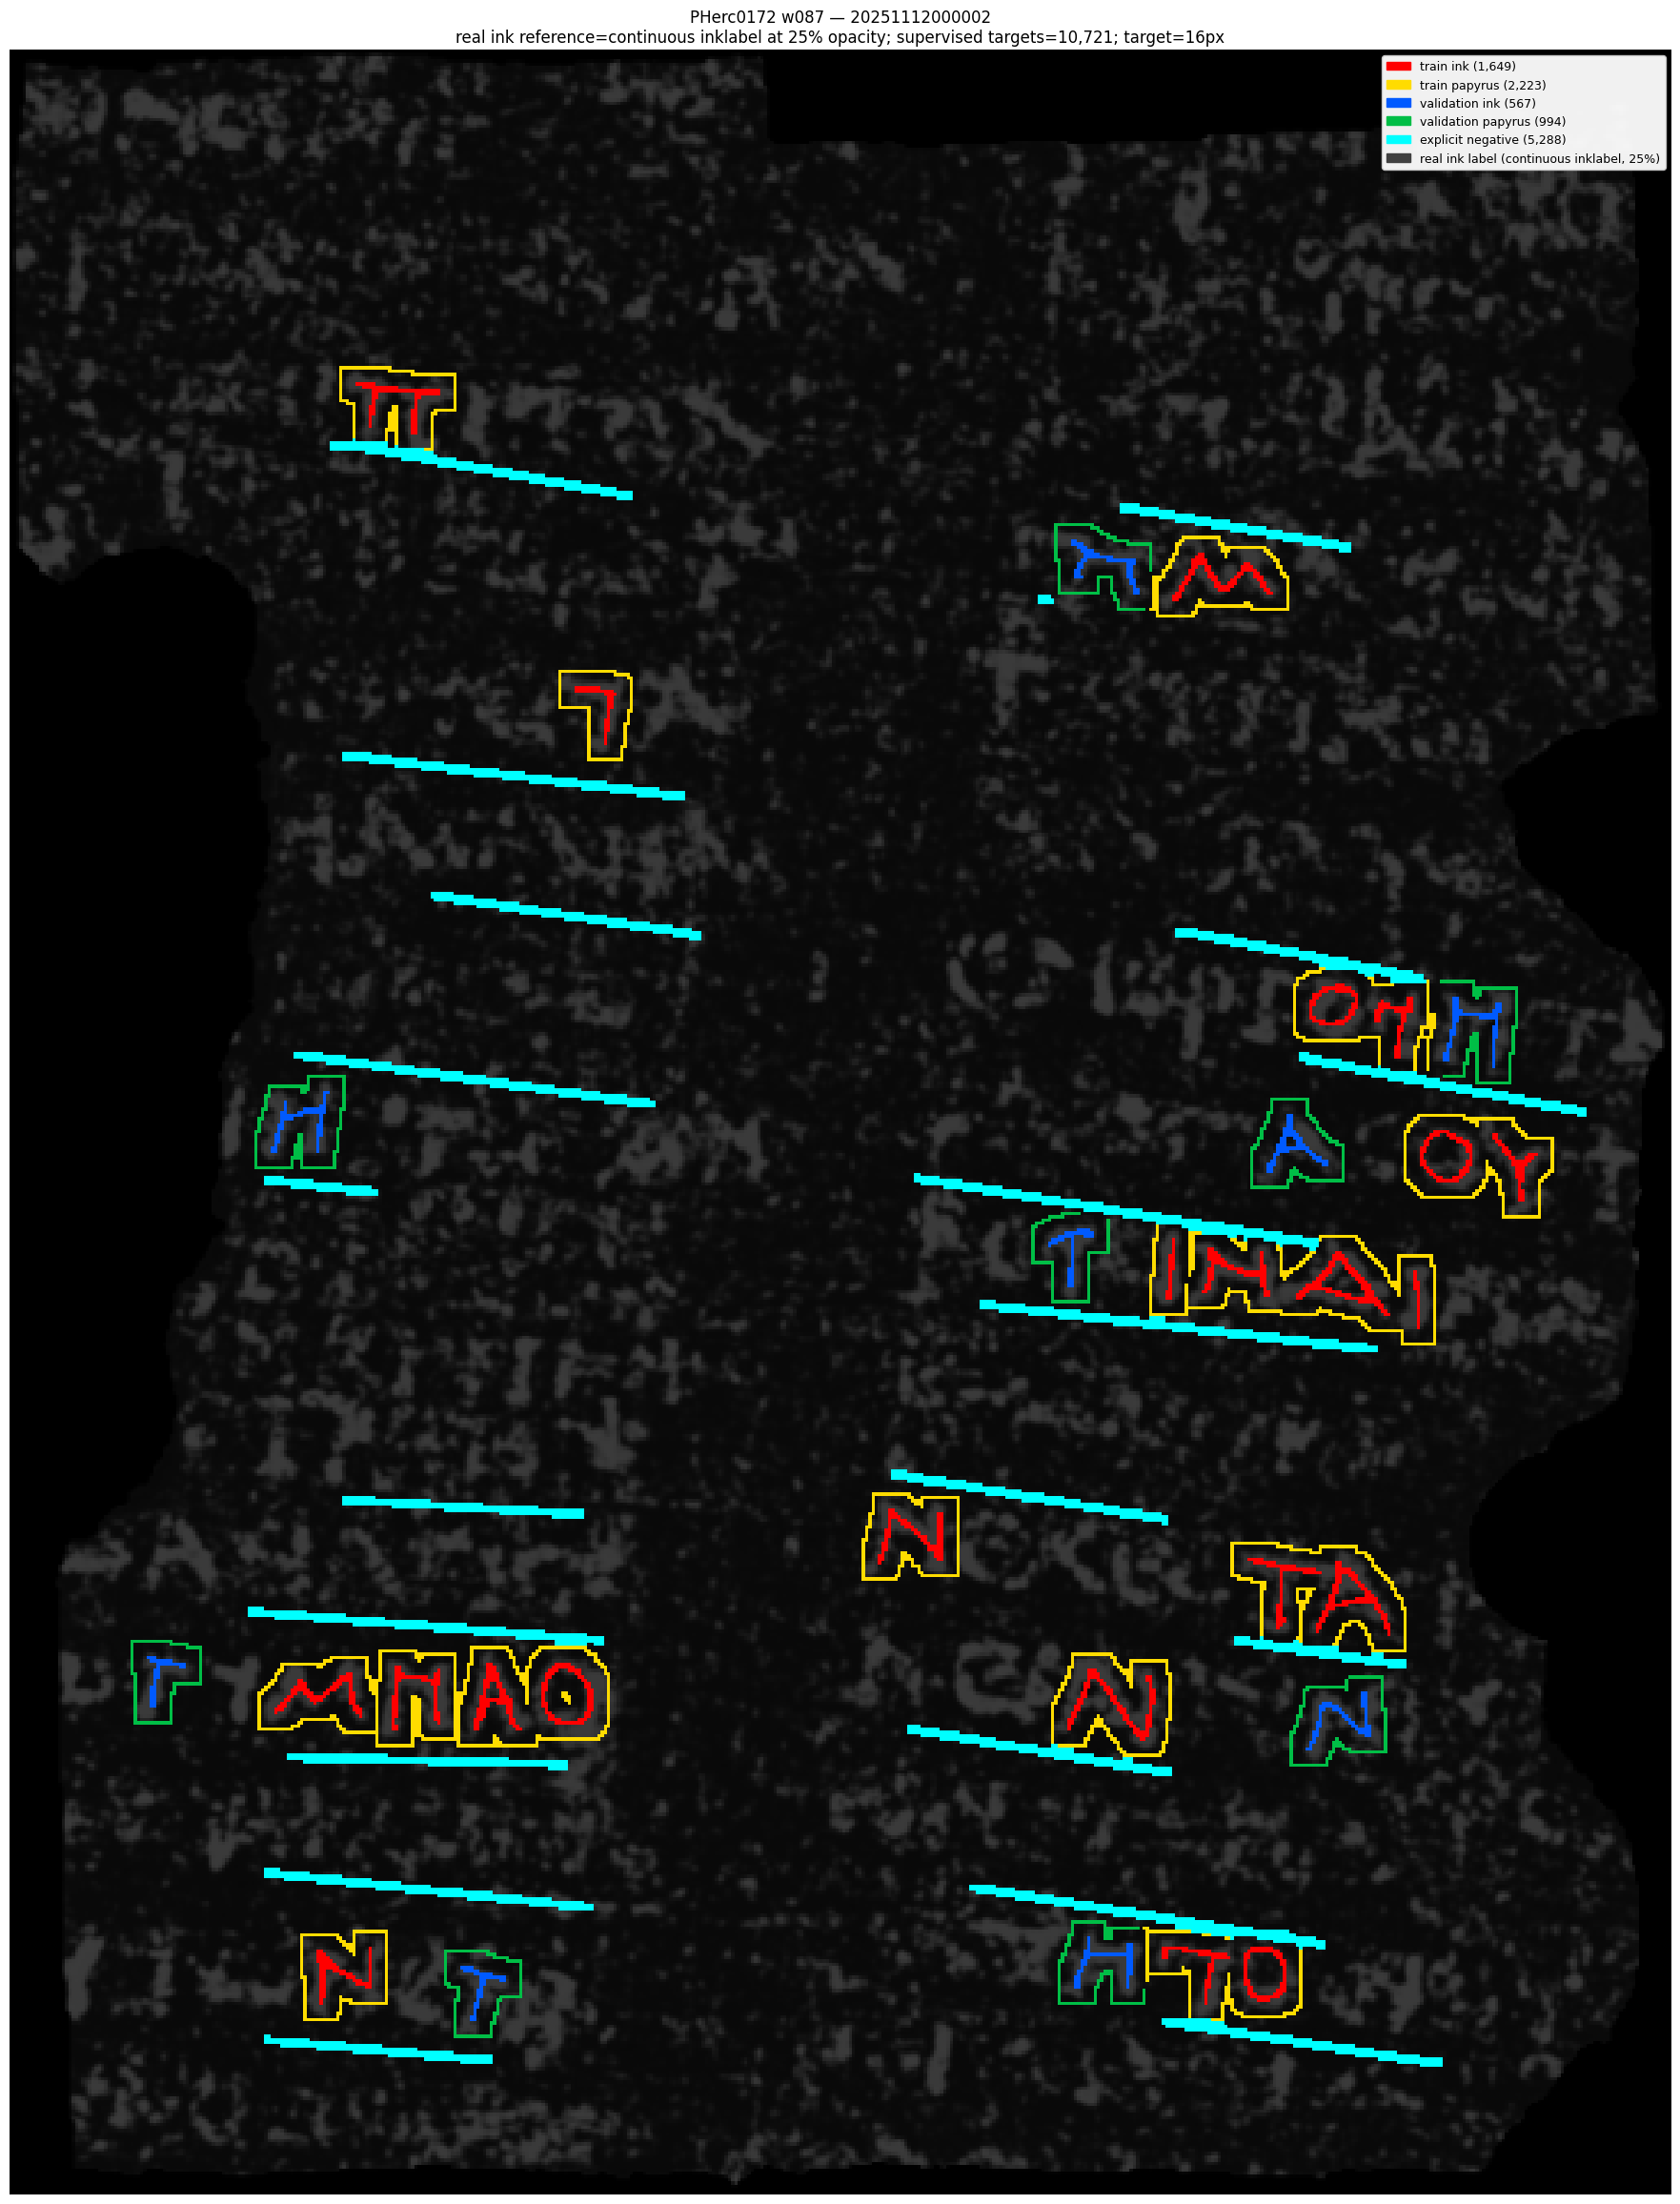

In [14]:
render_scroll(20251112000002, SCROLL_NAMES[20251112000002])

[split] scroll 20240304141531: manual mask=./train_masks/20240304141531.png train_pixels=18.4% explicit_negative_pixels=702,464
[split] scroll 20240304141531: axis=x train_frac=0.75
[ring] closed(base=eroded): CLOSE_R=3 GAP_R=3 exclusion_tiles=39475
[ring_negatives] source='closed' tile_radius=2  ink_tiles=11812  ring_tiles=18823  ratio=1.59
[manual-split] scroll 20240304141531: unit=16px train_ring=3599360px valid_ring=4243200px
[context-replace] scroll 20240304141531: 10222 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign25_split_audit/20240304141531_campaign25_split.png
{'train_ink': 3395, 'train_papyrus': 4231, 'valid_ink': 4057, 'valid_papyrus': 5007, 'explicit_negative': 2072}


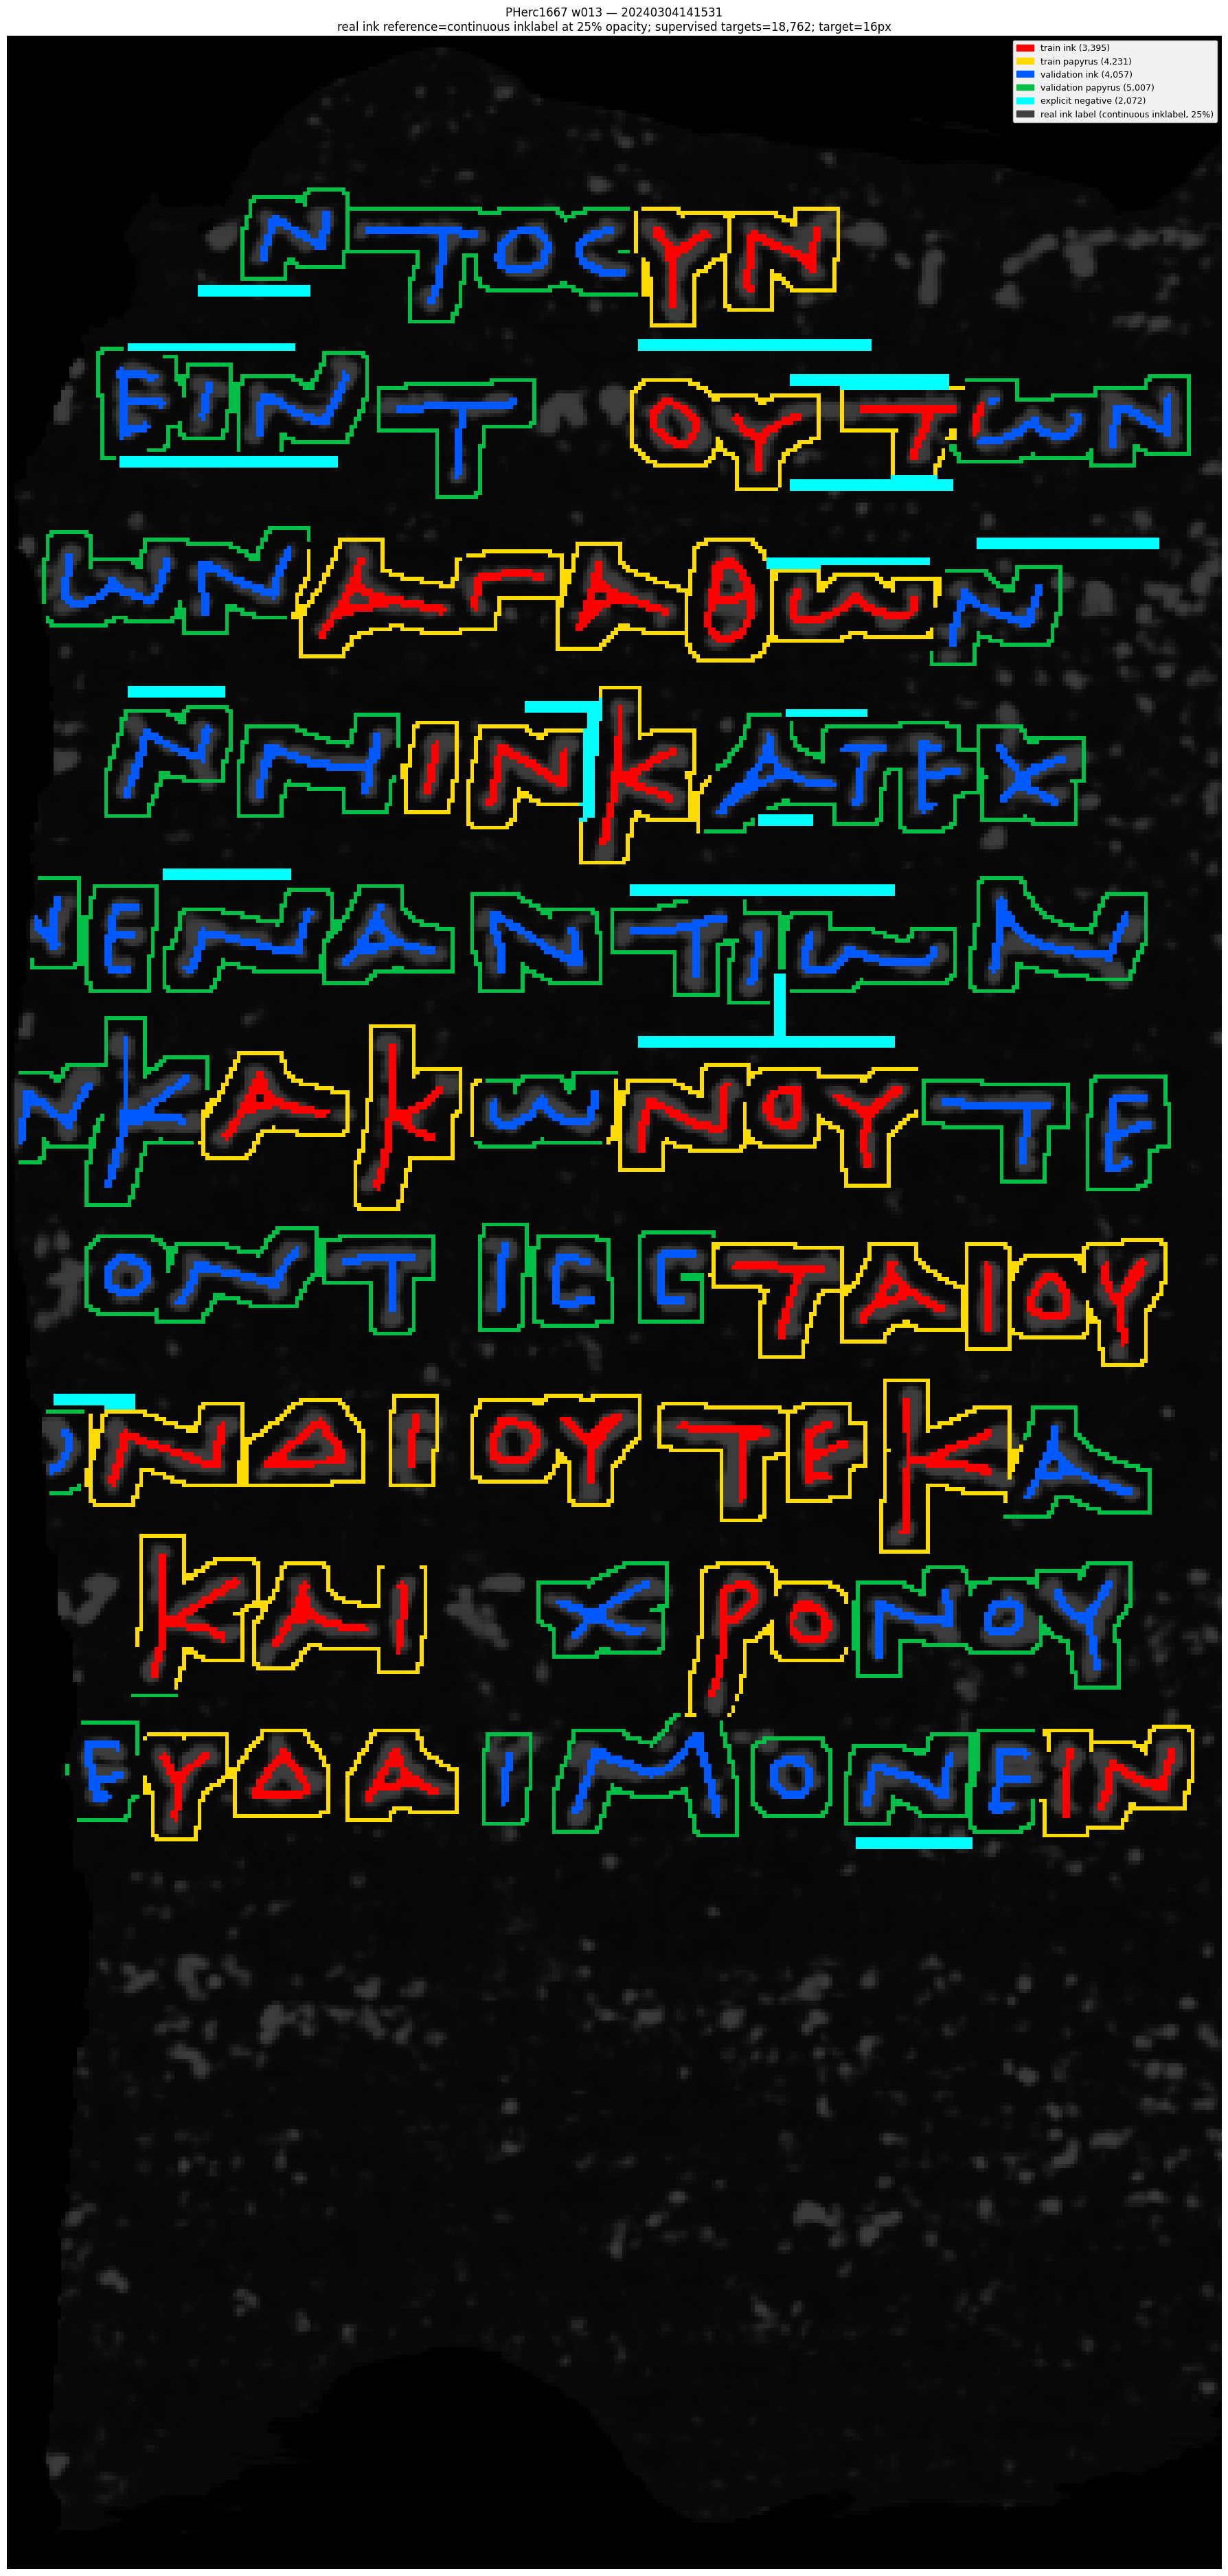

In [15]:
render_scroll(20240304141531, SCROLL_NAMES[20240304141531])

[split] scroll 20240304144031: manual mask=./train_masks/20240304144031.png train_pixels=4.1% explicit_negative_pixels=1,501,441
[split] scroll 20240304144031: axis=x train_frac=0.75
[ring] closed(base=eroded): CLOSE_R=3 GAP_R=3 exclusion_tiles=23105
[ring_negatives] source='closed' tile_radius=2  ink_tiles=6199  ring_tiles=11846  ratio=1.91
[manual-split] scroll 20240304144031: unit=16px train_ring=2828800px valid_ring=1790720px
[context-replace] scroll 20240304144031: 20397 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign25_split_audit/20240304144031_campaign25_split.png
{'train_ink': 2205, 'train_papyrus': 3473, 'valid_ink': 1368, 'valid_papyrus': 2298, 'explicit_negative': 4315}


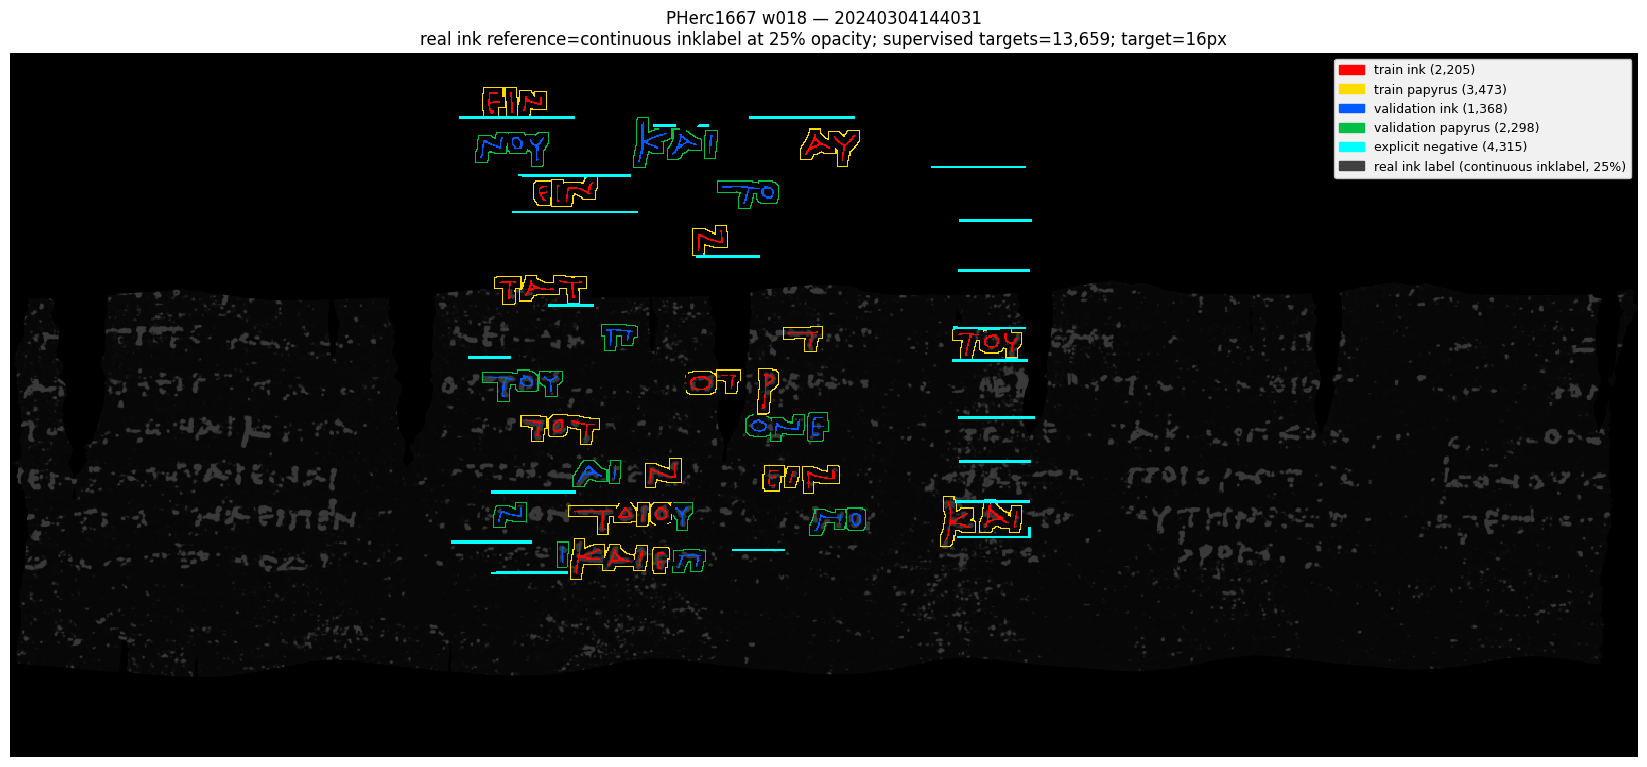

In [16]:
render_scroll(20240304144031, SCROLL_NAMES[20240304144031])

[split] scroll 20250919125754: manual mask=./train_masks/20250919125754.png train_pixels=5.8% explicit_negative_pixels=488,960
[split] scroll 20250919125754: axis=x train_frac=0.75
[ring] closed(base=eroded): CLOSE_R=3 GAP_R=3 exclusion_tiles=5360
[ring_negatives] source='closed' tile_radius=2  ink_tiles=1529  ring_tiles=2144  ratio=1.40
[manual-split] scroll 20250919125754: unit=16px train_ring=652800px valid_ring=287488px
[context-replace] scroll 20250919125754: 2446 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign25_split_audit/20250919125754_campaign25_split.png
{'train_ink': 638, 'train_papyrus': 595, 'valid_ink': 247, 'valid_papyrus': 320, 'explicit_negative': 1513}


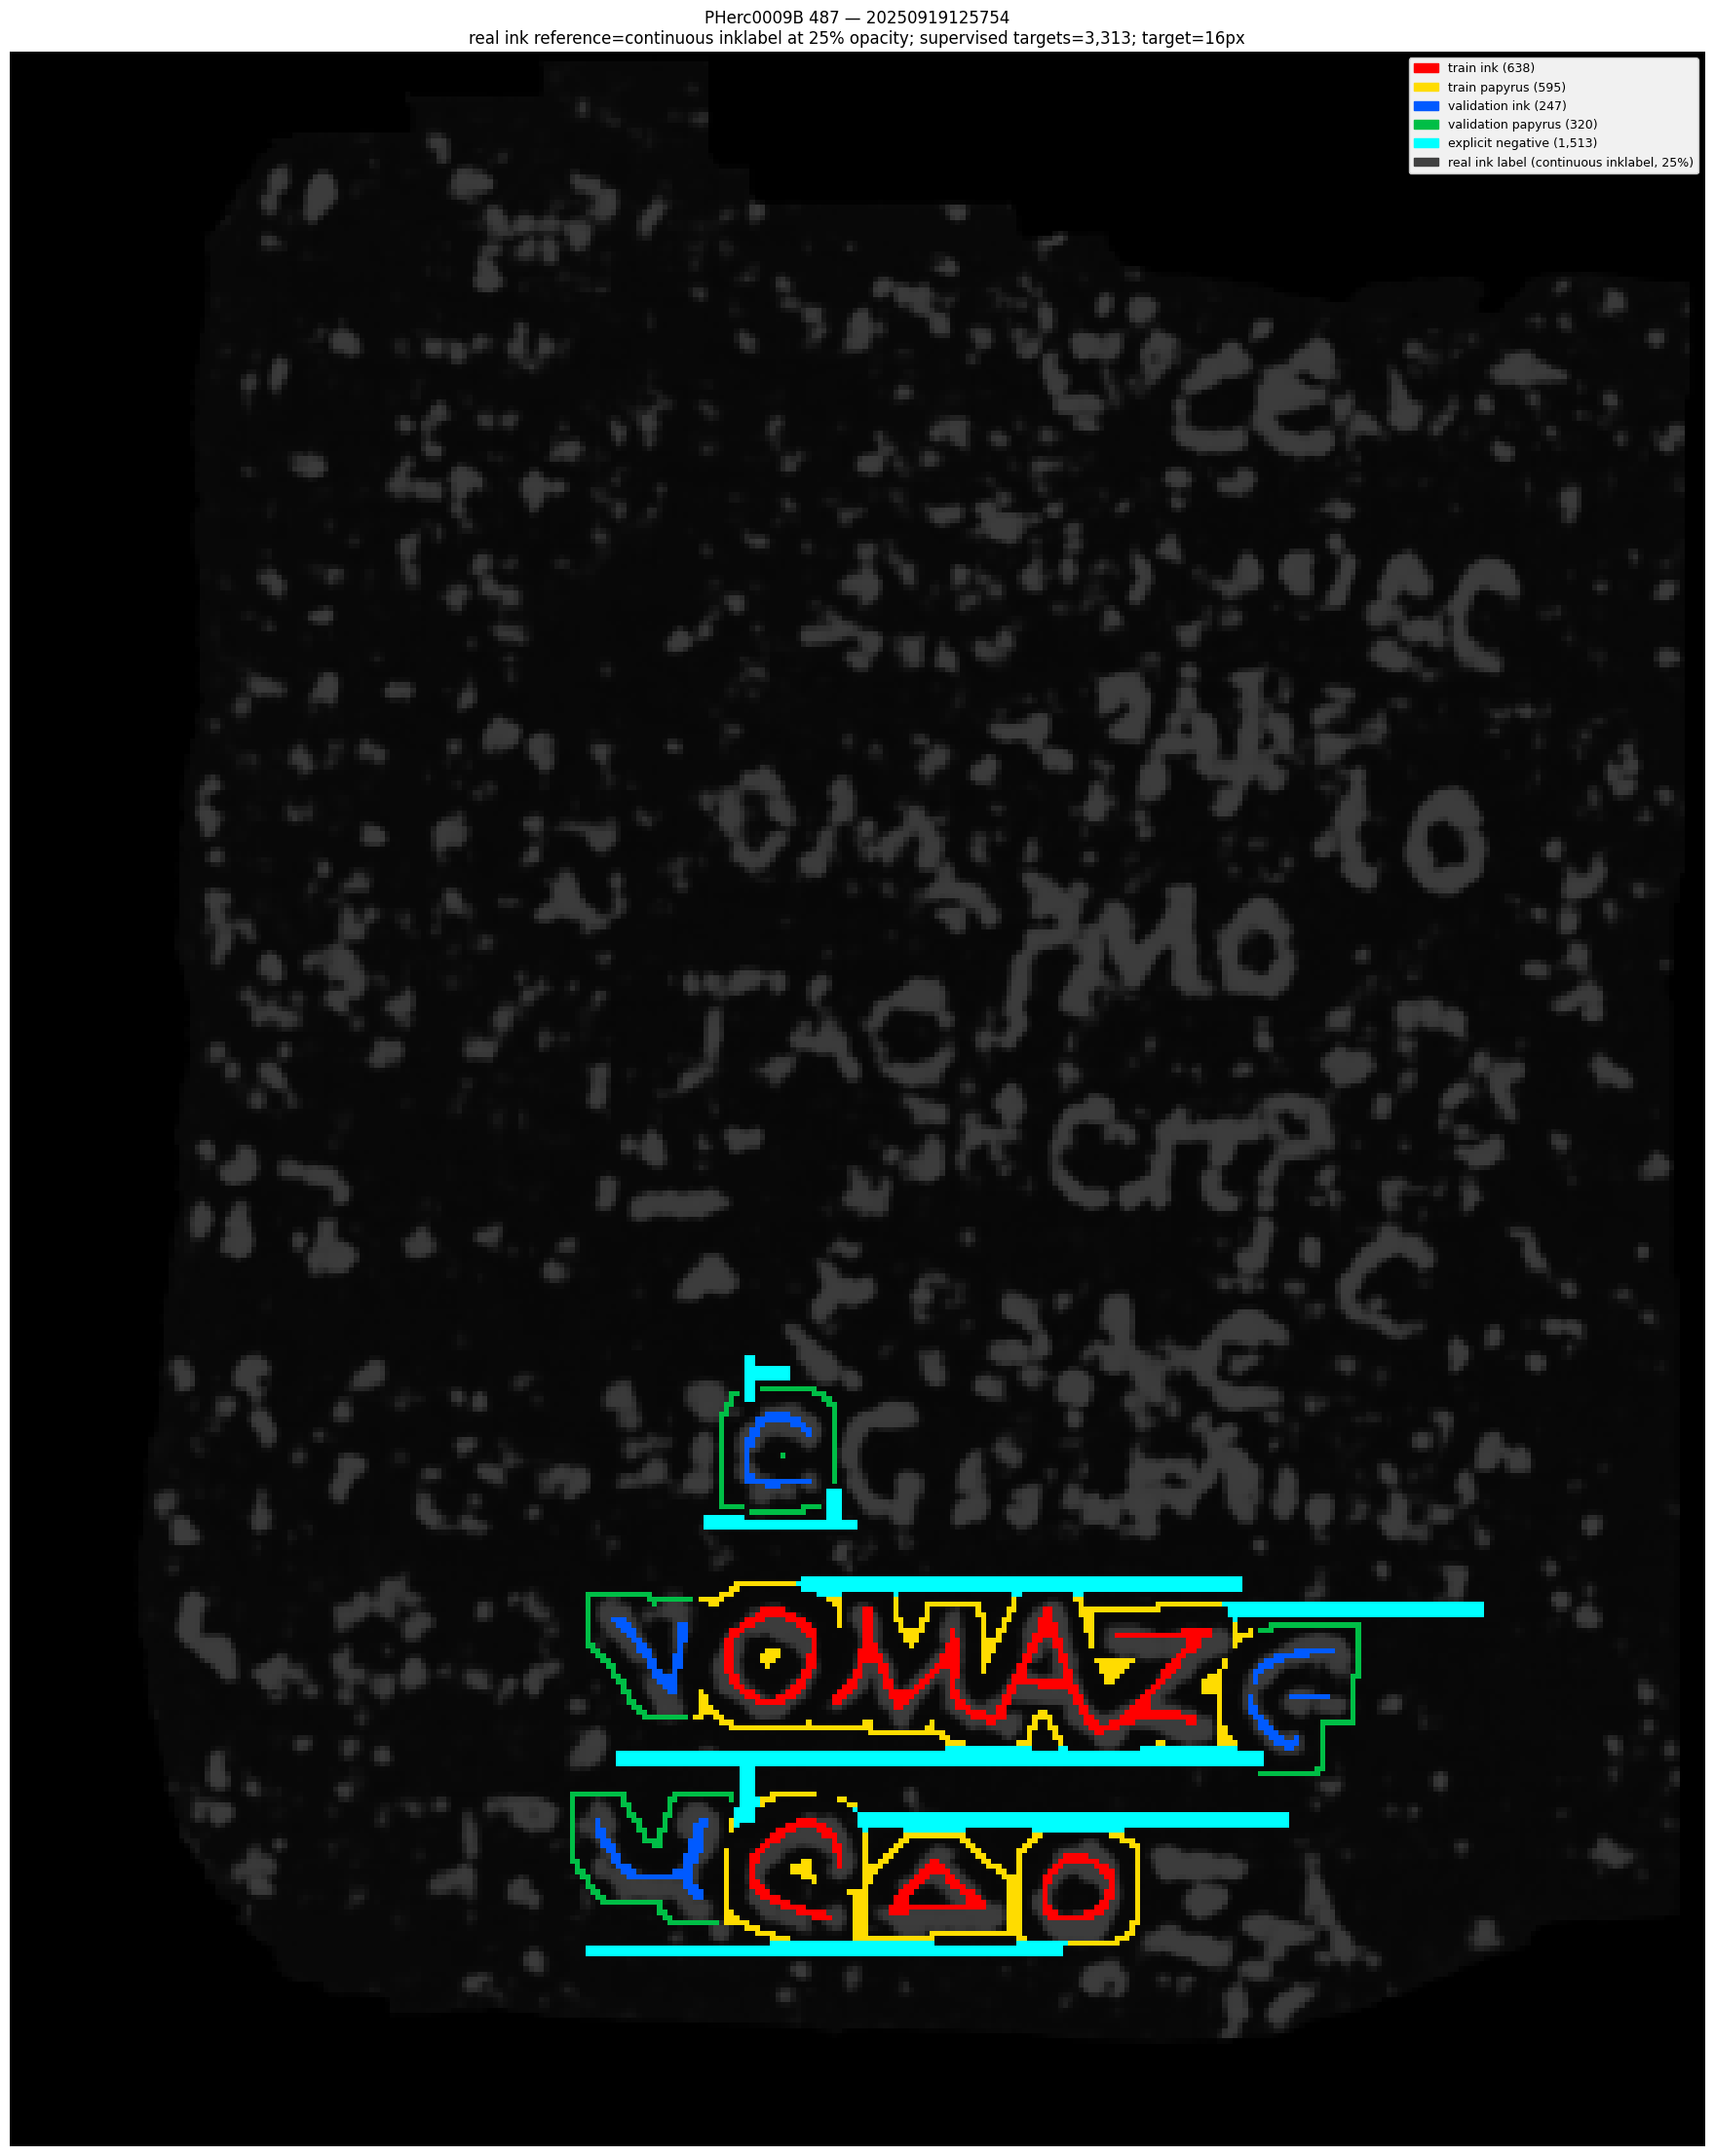

In [17]:
render_scroll(20250919125754, SCROLL_NAMES[20250919125754])

[split] scroll 20231210121321: manual mask=./train_masks/20231210121321.png train_pixels=10.9% explicit_negative_pixels=1,645,056
[split] scroll 20231210121321: axis=x train_frac=0.75
[ring] closed(base=eroded): CLOSE_R=3 GAP_R=3 exclusion_tiles=32130
[ring_negatives] source='closed' tile_radius=2  ink_tiles=9640  ring_tiles=14731  ratio=1.53
[manual-split] scroll 20231210121321: unit=16px train_ring=3776256px valid_ring=2462720px
[context-replace] scroll 20231210121321: 25578 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign25_split_audit/20231210121321_campaign25_split.png
{'train_ink': 3574, 'train_papyrus': 4342, 'valid_ink': 2464, 'valid_papyrus': 2841, 'explicit_negative': 4722}


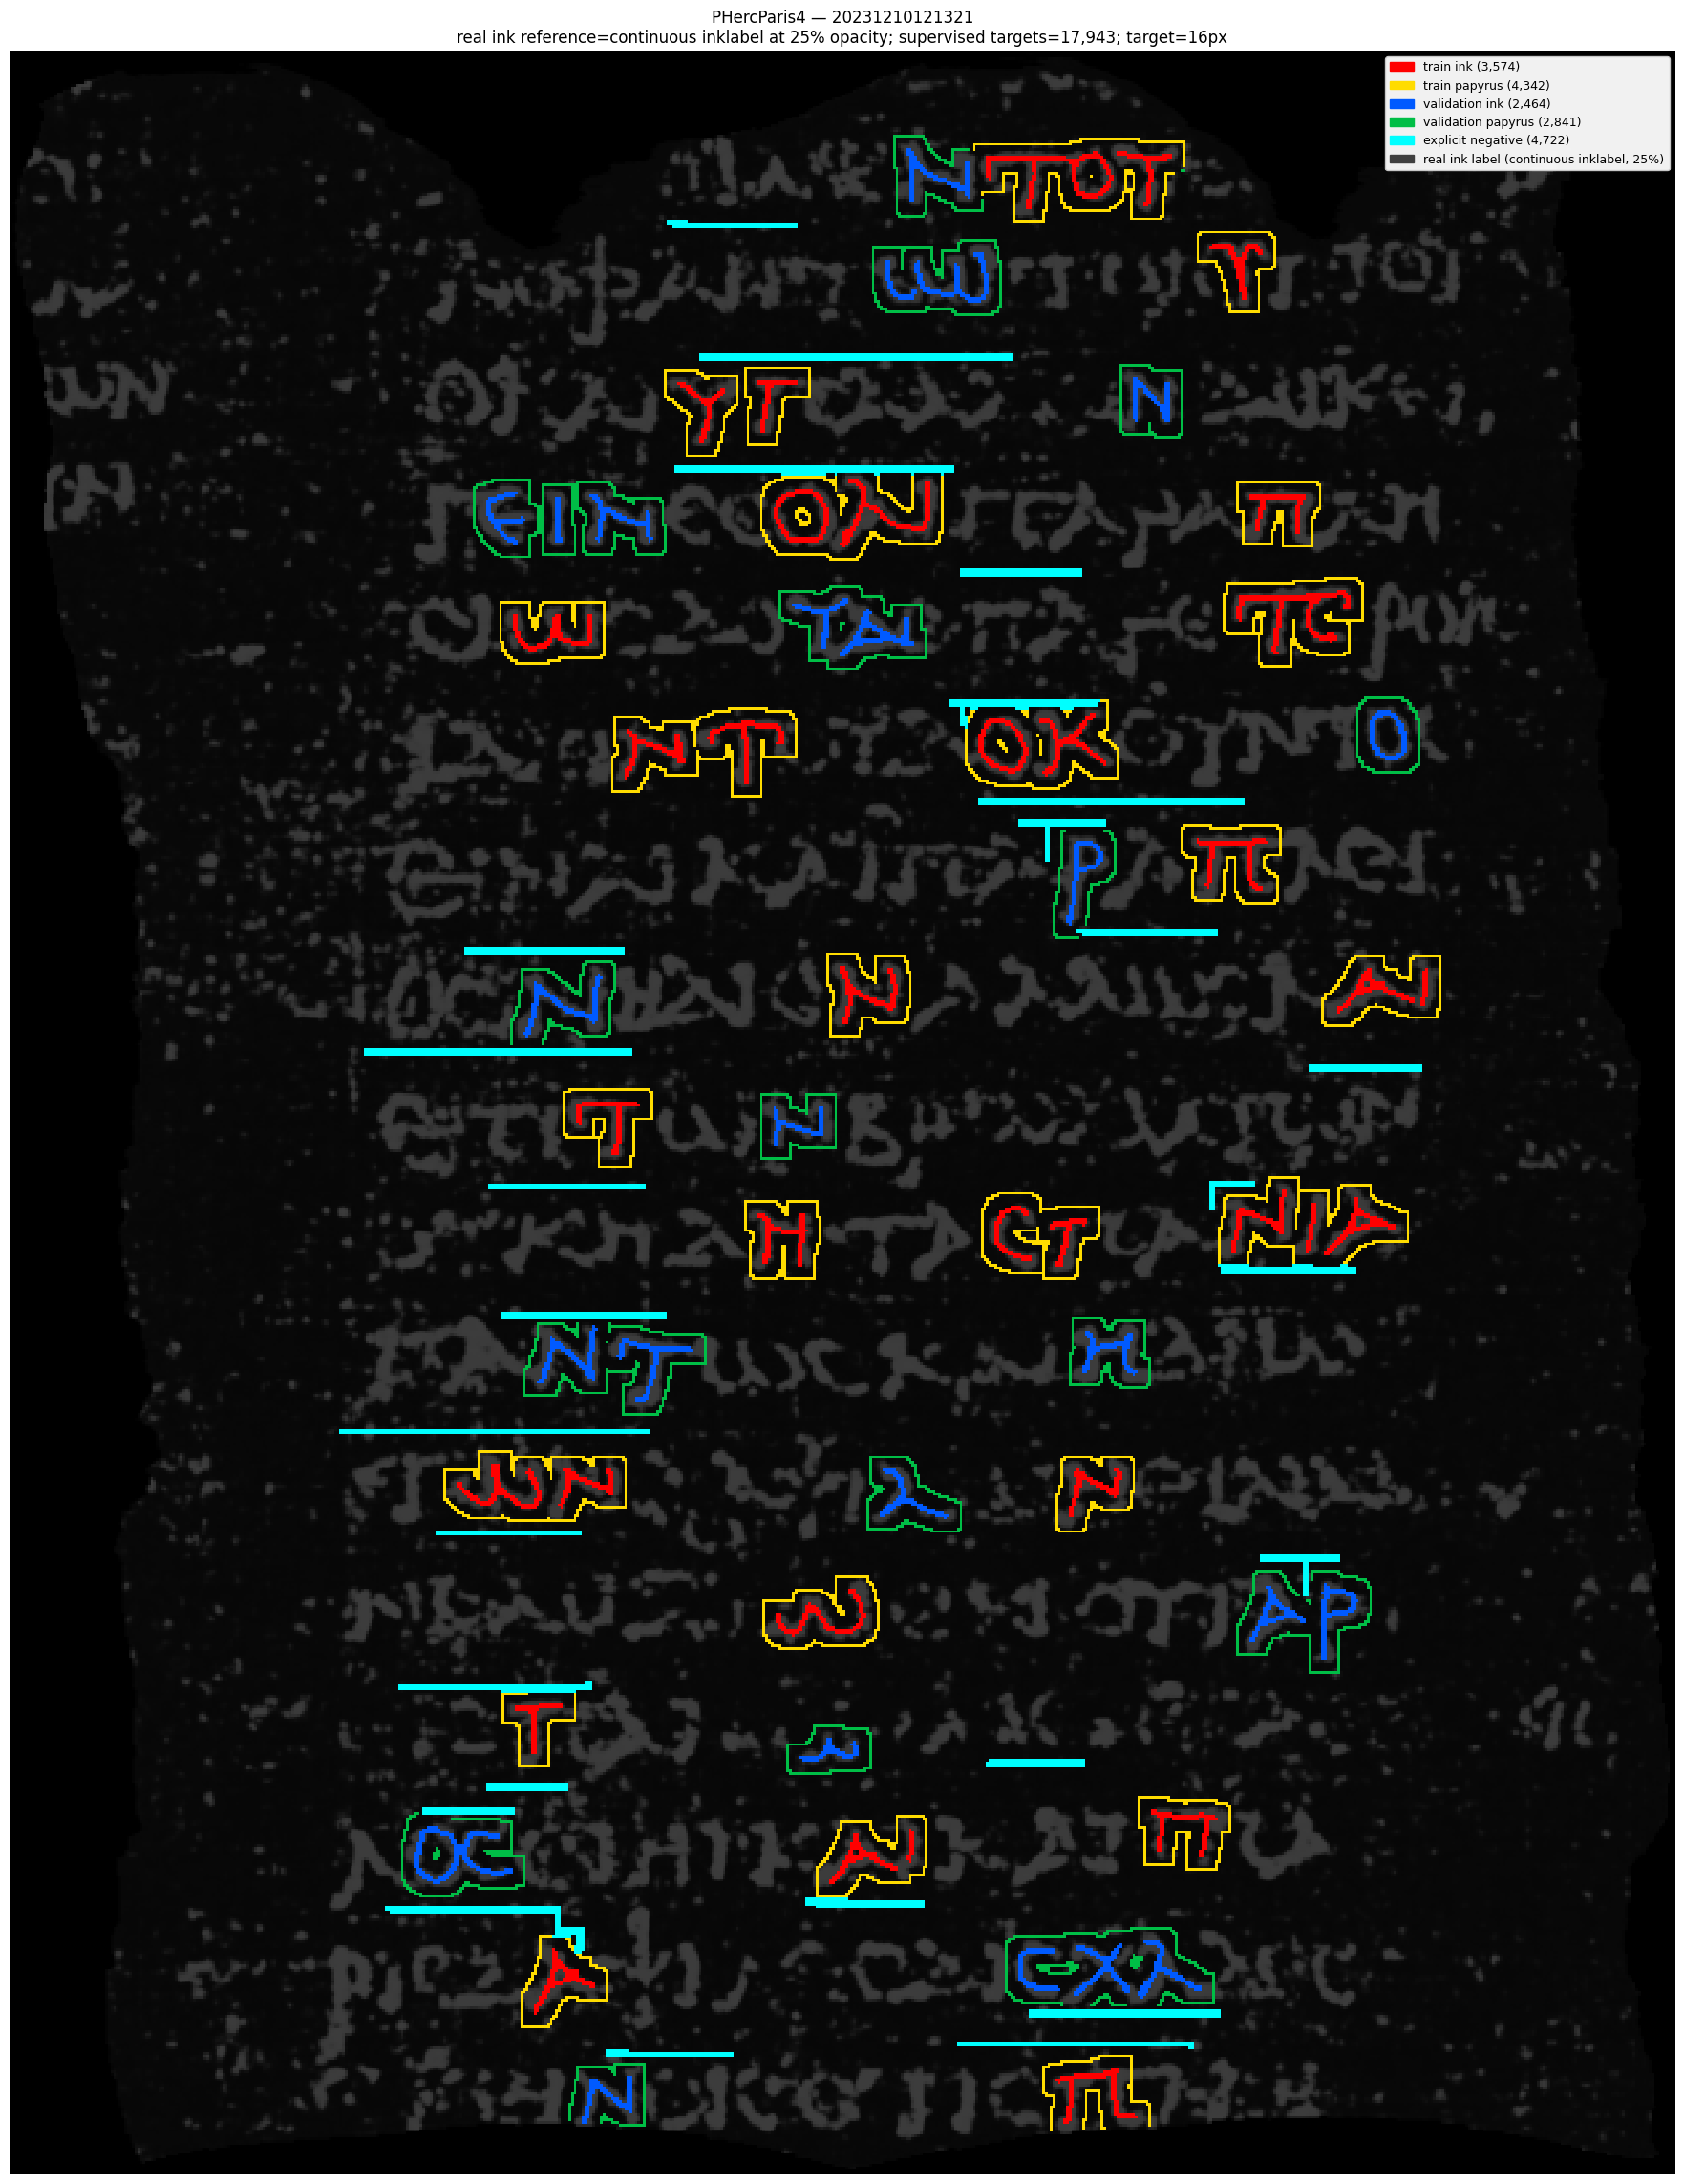

In [18]:
render_scroll(20231210121321, SCROLL_NAMES[20231210121321])

[split] scroll 20250628074500: manual mask=./train_masks/20250628074500.png train_pixels=11.8% explicit_negative_pixels=862,976
[split] scroll 20250628074500: axis=x train_frac=0.6
[ring] closed(base=eroded): CLOSE_R=3 GAP_R=3 exclusion_tiles=7608
[ring_negatives] source='closed' tile_radius=2  ink_tiles=2308  ring_tiles=3320  ratio=1.44
[manual-split] scroll 20250628074500: unit=16px train_ring=878848px valid_ring=561920px
[context-replace] scroll 20250628074500: 3395 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign25_split_audit/20250628074500_campaign25_split.png
{'train_ink': 1012, 'train_papyrus': 604, 'valid_ink': 494, 'valid_papyrus': 591, 'explicit_negative': 2568}


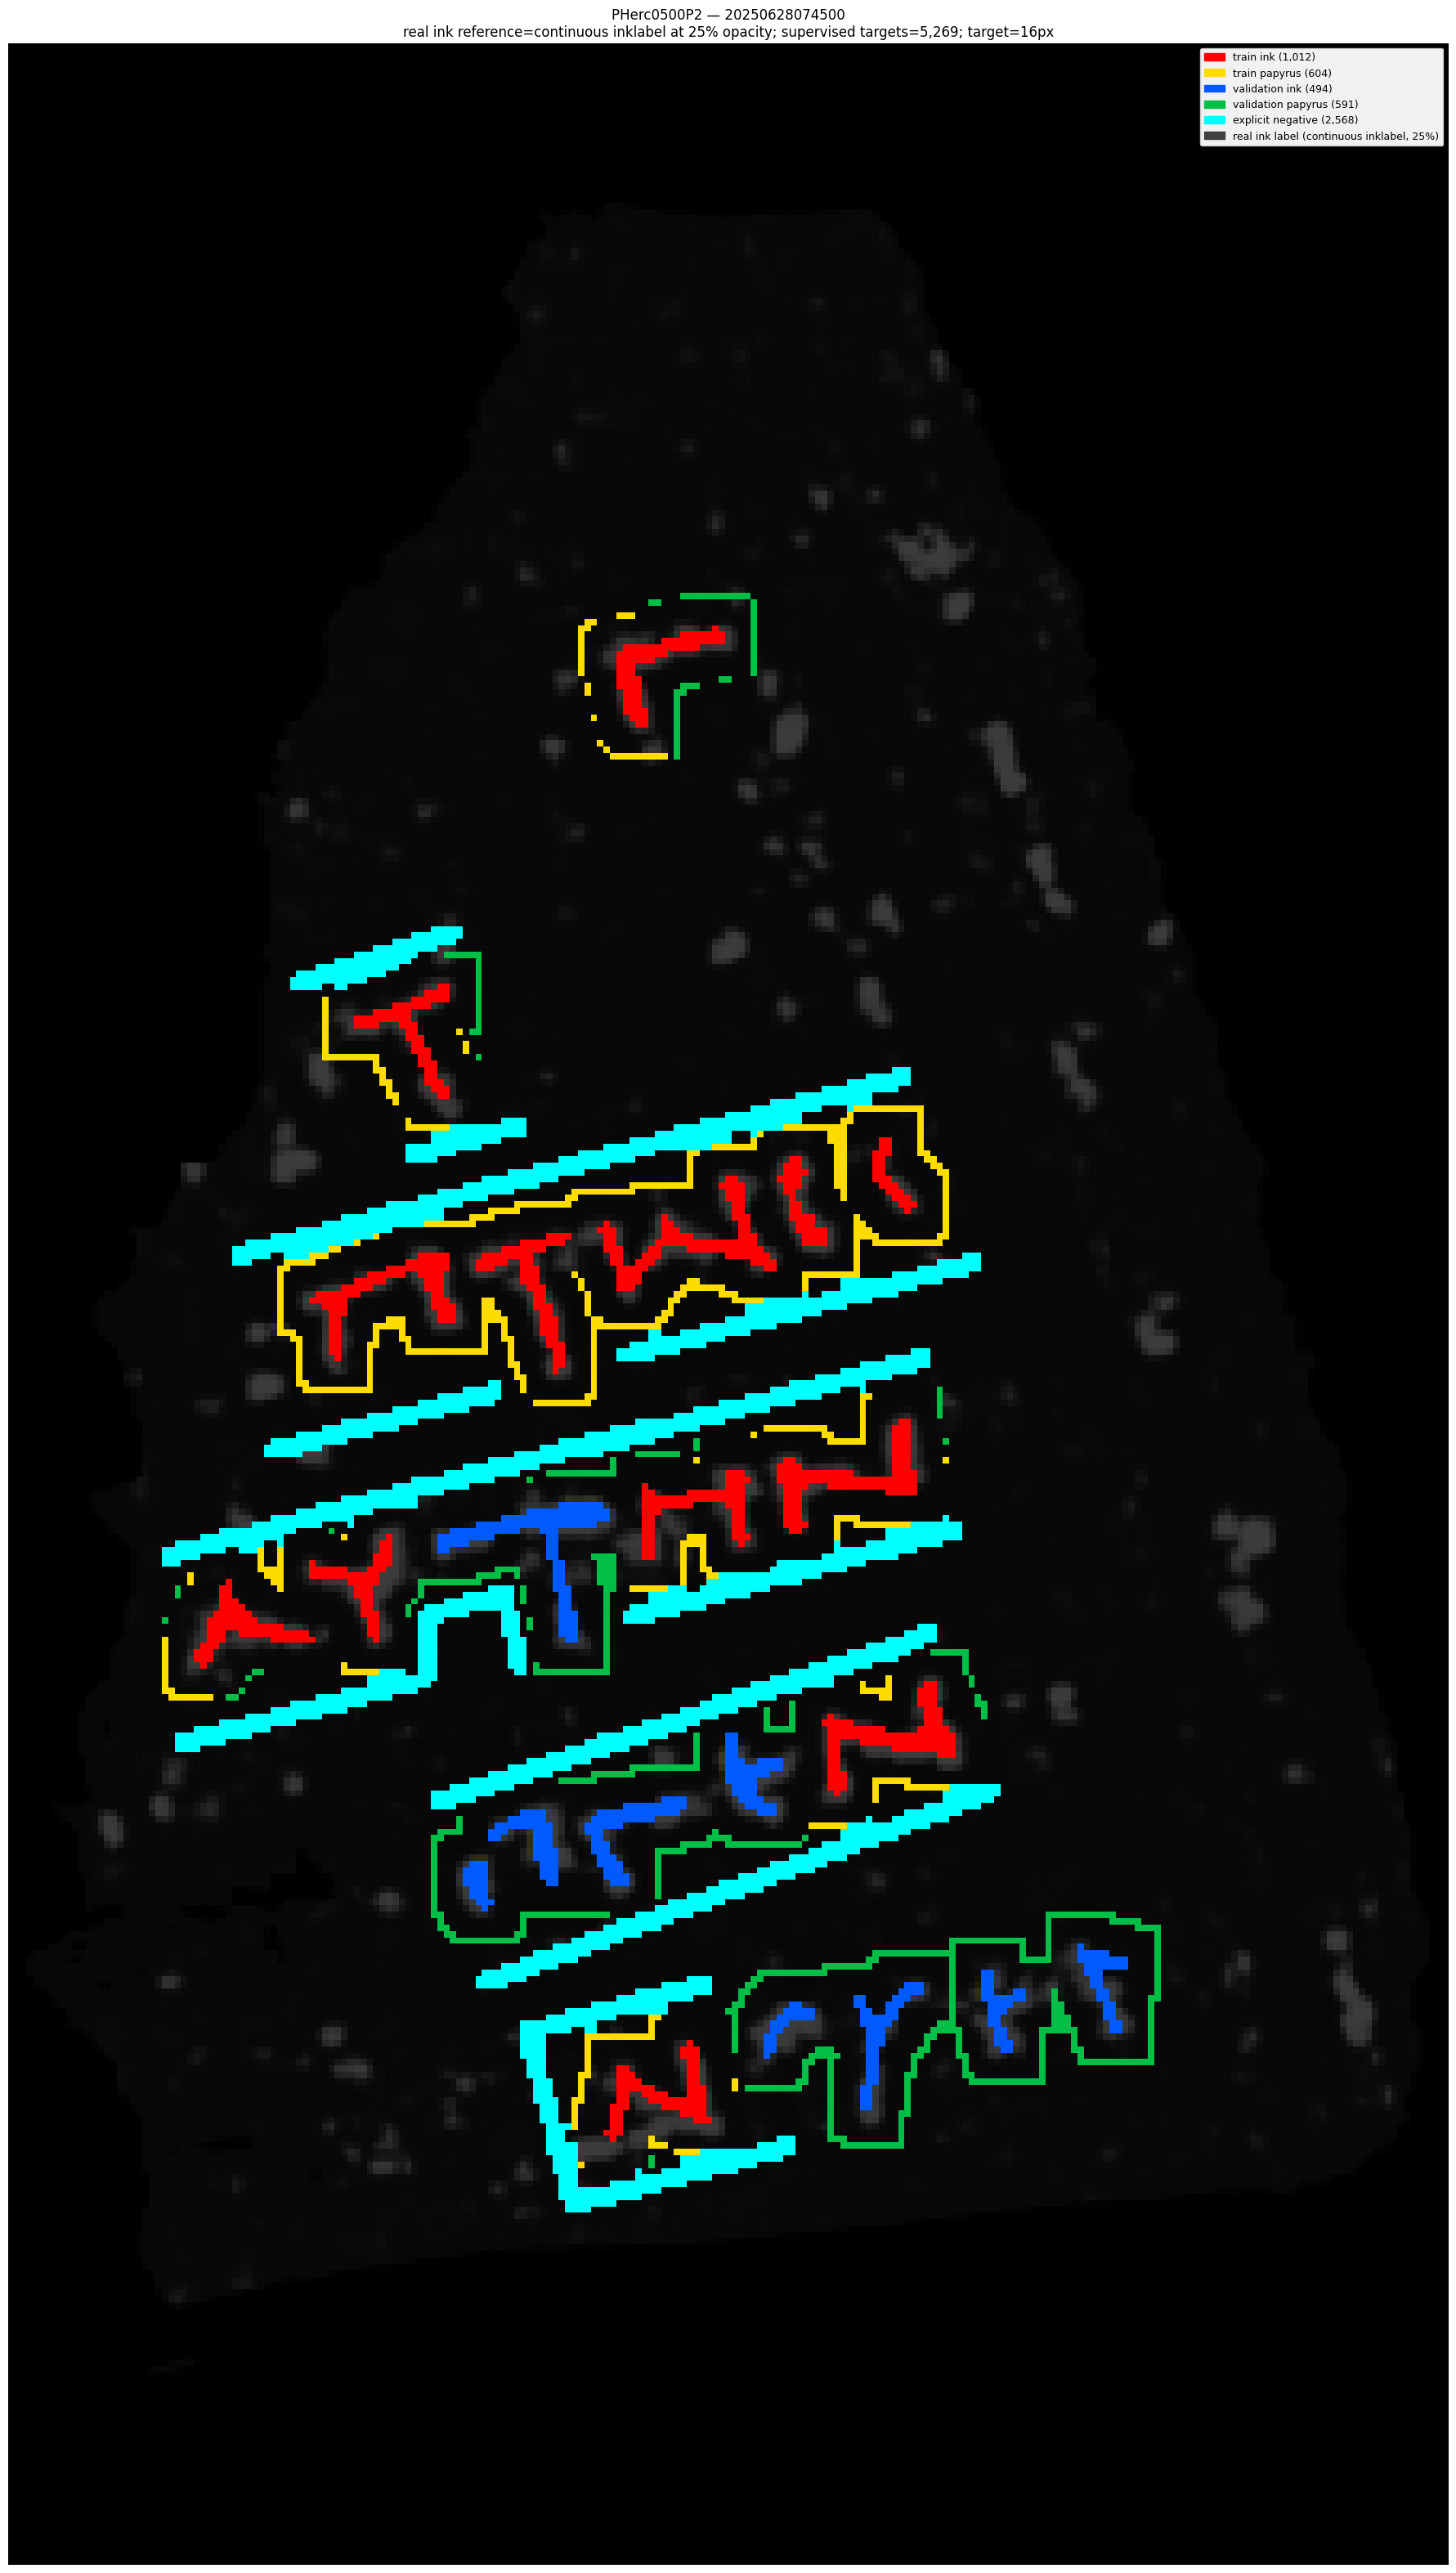

In [19]:
render_scroll(20250628074500, SCROLL_NAMES[20250628074500])

[split] scroll 20260226000000: manual mask=./train_masks/20260226000000.png train_pixels=8.9% explicit_negative_pixels=188,284
[split] scroll 20260226000000: axis=y train_frac=0.75
[ring] closed(base=eroded): CLOSE_R=3 GAP_R=3 exclusion_tiles=2138
[ring_negatives] source='closed' tile_radius=2  ink_tiles=646  ring_tiles=904  ratio=1.40
[manual-split] scroll 20260226000000: unit=16px train_ring=260096px valid_ring=136704px
[context-replace] scroll 20260226000000: 496 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign25_split_audit/20260226000000_campaign25_split.png
{'train_ink': 236, 'train_papyrus': 140, 'valid_ink': 142, 'valid_papyrus': 111, 'explicit_negative': 572}


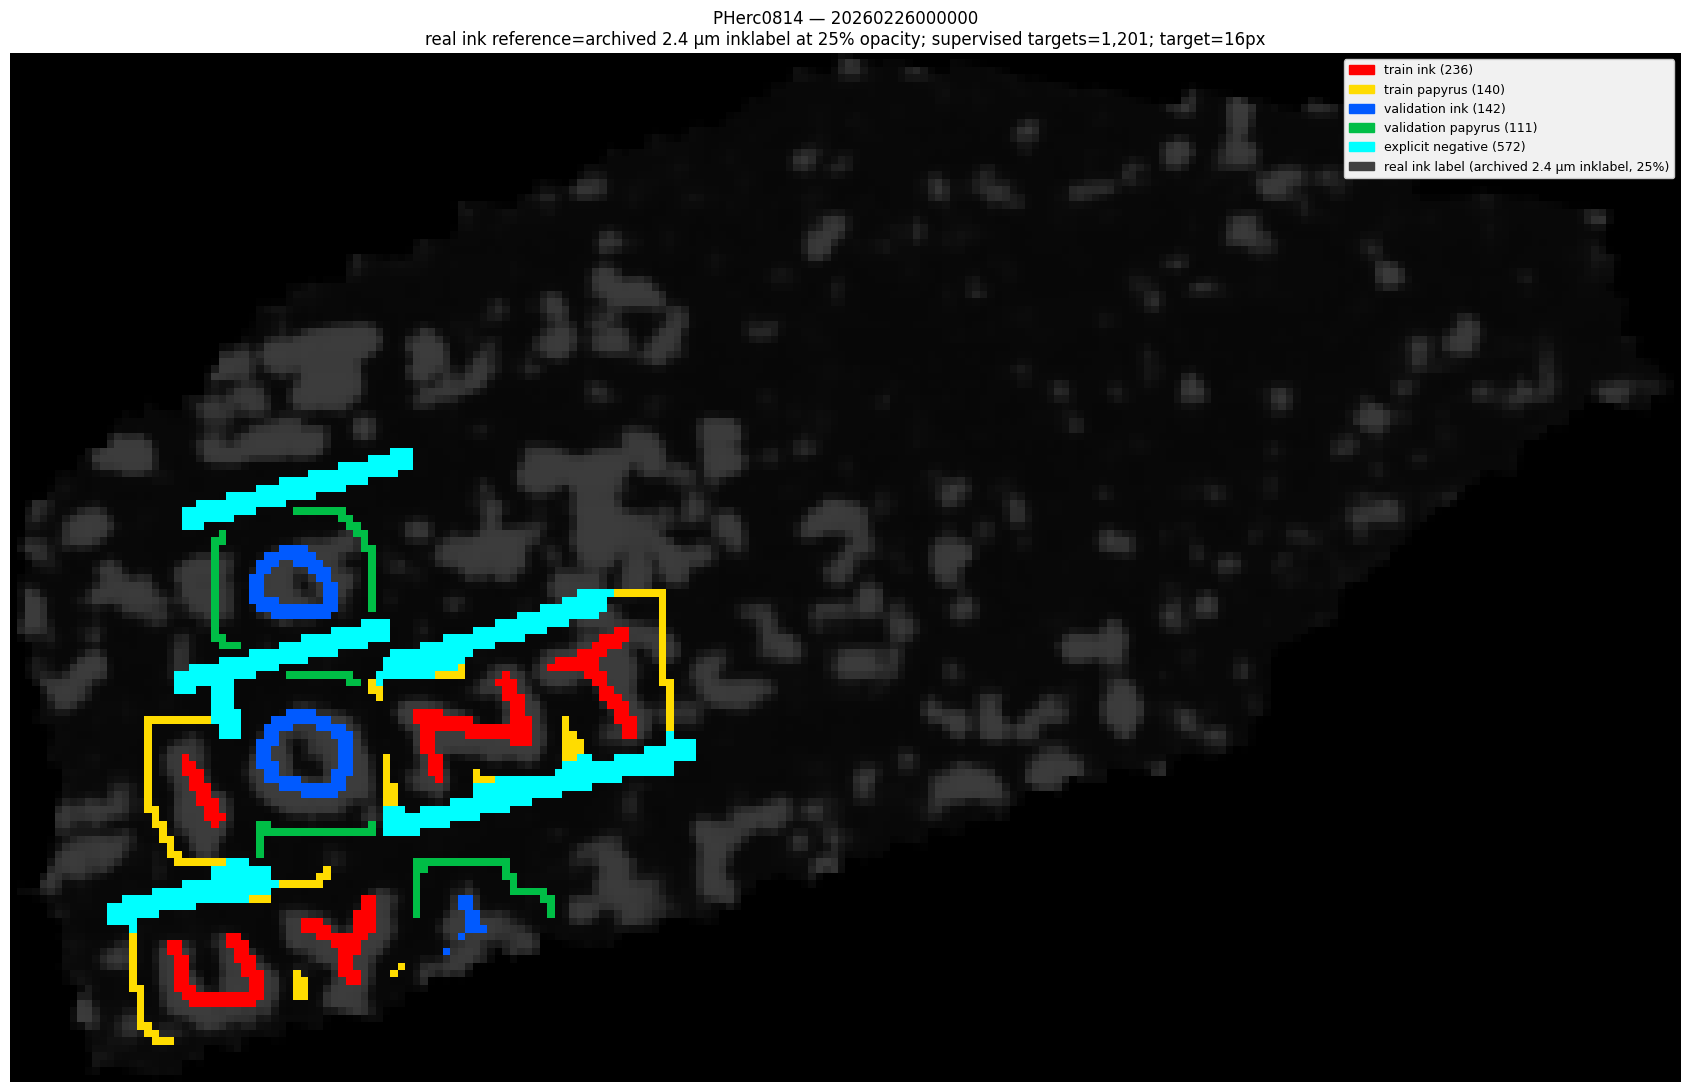

In [20]:
render_scroll(20260226000000, SCROLL_NAMES[20260226000000])